# Bayesian Router Simulations and Talk Workbook

This notebook now has two jobs:
1. build intuition for the router mechanics
2. connect those mechanics to the exact production story used in the talk

It covers:
1. **Reward weight sensitivity** (Section 35)
2. **Decay mechanism tuning** (Section 37)
3. **Validation scenarios** (Section 42)
4. **Real package behavior** for continuous rewards, expert priors, fallback, shadow evaluation, and circuit breakers

Recommended use:
- skim the markdown cells first for the story
- run the code cells to see how each mechanism behaves
- use the later sections to connect the toy simulations to the actual talk implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque
from dataclasses import dataclass
from typing import Dict, List

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Reproducibility
np.random.seed(42)

## Part 1: Reward Weight Sensitivity Analysis (Section 35)

How do different reward weights affect model selection?

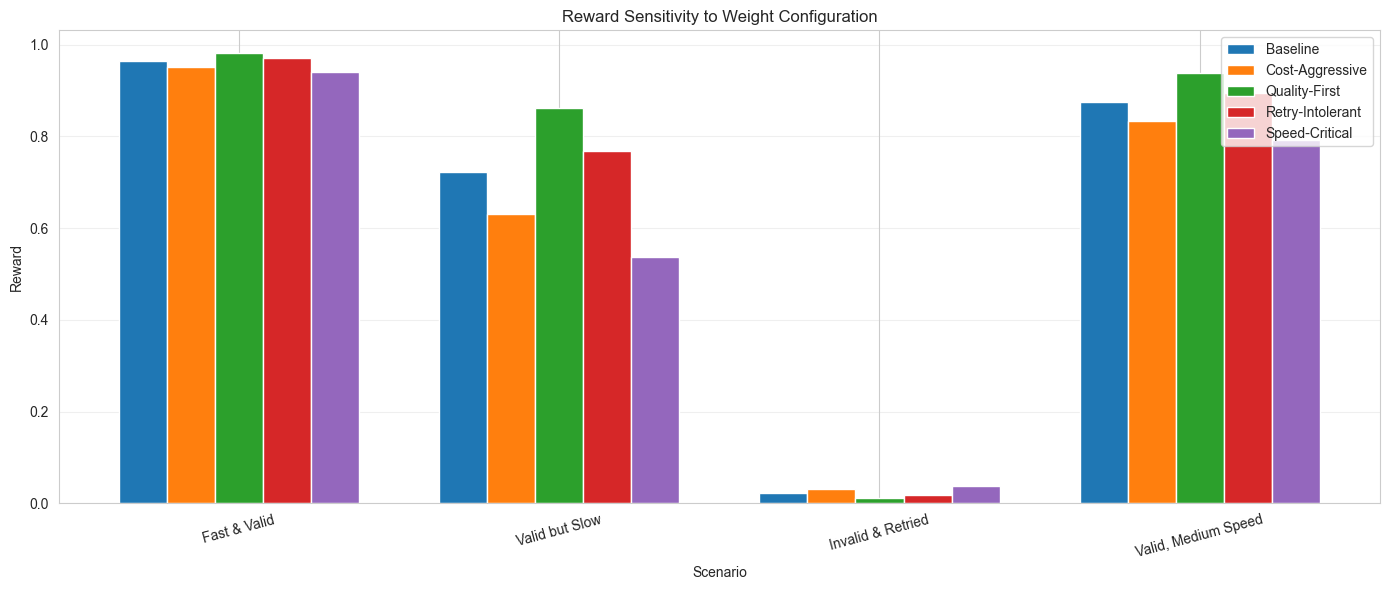


Reward values by configuration:

Baseline:
  Fast & Valid        : 0.964
  Valid but Slow      : 0.723
  Invalid & Retried   : 0.023
  Valid, Medium Speed : 0.875

Cost-Aggressive:
  Fast & Valid        : 0.952
  Valid but Slow      : 0.630
  Invalid & Retried   : 0.030
  Valid, Medium Speed : 0.833

Quality-First:
  Fast & Valid        : 0.982
  Valid but Slow      : 0.861
  Invalid & Retried   : 0.011
  Valid, Medium Speed : 0.937

Retry-Intolerant:
  Fast & Valid        : 0.970
  Valid but Slow      : 0.769
  Invalid & Retried   : 0.019
  Valid, Medium Speed : 0.896

Speed-Critical:
  Fast & Valid        : 0.940
  Valid but Slow      : 0.538
  Invalid & Retried   : 0.038
  Valid, Medium Speed : 0.791



In [2]:
# --- COMPOSITE REWARD FUNCTIONS ---
# Instead of asking humans to rate every LLM response, the router
# builds its own score from three signals already in production telemetry.
# This is the central claim of the talk: no human labels needed.

def compute_latency_reward(latency_ms, max_reward=0.30, midpoint=2000, steepness=600):
    # A sigmoid curve converts raw latency into a reward in [0, max_reward].
    # Intuition: responses faster than 2000ms get close to full credit;
    # responses slower than 2000ms get penalized smoothly, not with a hard cutoff.
    # midpoint=2000 means "at exactly 2000ms you get half the max latency reward".
    # steepness=600 controls how steep the penalty curve is around the midpoint.
    return max_reward / (1 + np.exp((latency_ms - midpoint) / steepness))

def compute_reward(valid, retried, latency_ms, weights):
    # Three binary/continuous signals -> one composite score in [0, 1].
    # Each signal contributes its weight independently, then they sum.
    # The weights must sum to 1.0 (50% + 30% + 20% = 100%).
    r_validity = weights['validity'] if valid else 0.0   # full credit or zero
    r_retry = weights['retry'] if not retried else 0.0   # full credit or zero
    r_latency = compute_latency_reward(                  # smooth value in [0, latency_weight]
        latency_ms,
        max_reward=weights['latency']
    )
    return r_validity + r_latency + r_retry

# --- FOUR REPRESENTATIVE RESPONSE SCENARIOS ---
# These simulate what production telemetry might look like for different responses.
scenarios = [
    {'name': 'Fast & Valid', 'valid': True, 'retried': False, 'latency': 800},    # ideal
    {'name': 'Valid but Slow', 'valid': True, 'retried': False, 'latency': 3500}, # penalty for latency
    {'name': 'Invalid & Retried', 'valid': False, 'retried': True, 'latency': 3500}, # worst case
    {'name': 'Valid, Medium Speed', 'valid': True, 'retried': False, 'latency': 1800}, # typical
]

# --- FIVE WEIGHT CONFIGURATIONS ---
# Each config answers a different business priority:
# - Who you are (latency-sensitive vs. quality-focused) changes which config fits best.
# - The weights stay with your deployment, not the algorithm.
configs = {
    'Baseline':        {'validity': 0.50, 'latency': 0.30, 'retry': 0.20},  # general production
    'Cost-Aggressive': {'validity': 0.40, 'latency': 0.40, 'retry': 0.20},  # favour fast/cheap
    'Quality-First':   {'validity': 0.70, 'latency': 0.15, 'retry': 0.15},  # favour correctness
    'Retry-Intolerant':{'validity': 0.45, 'latency': 0.25, 'retry': 0.30},  # punish retries hard
    'Speed-Critical':  {'validity': 0.35, 'latency': 0.50, 'retry': 0.15},  # latency dominates
}

# Compute rewards for every (config, scenario) pair.
# The resulting table shows how the same response scores differently
# depending on what your business cares about.
results = defaultdict(dict)
for config_name, weights in configs.items():
    for scenario in scenarios:
        reward = compute_reward(
            scenario['valid'],
            scenario['retried'],
            scenario['latency'],
            weights
        )
        results[config_name][scenario['name']] = reward

# Bar chart: each group of bars is one scenario, each bar is one weight config.
# Look for which config best separates "Fast & Valid" from "Invalid & Retried" -
# that gap is what teaches the router which model to prefer.
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(scenarios))
width = 0.15

for i, (config_name, scenario_rewards) in enumerate(results.items()):
    rewards = [scenario_rewards[s['name']] for s in scenarios]
    ax.bar(x + i*width, rewards, width, label=config_name)

ax.set_xlabel('Scenario')
ax.set_ylabel('Reward')
ax.set_title('Reward Sensitivity to Weight Configuration')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([s['name'] for s in scenarios], rotation=15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print exact numbers so you can see the spread at a glance.
print("\nReward values by configuration:\n")
for config_name in configs.keys():
    print(f"{config_name}:")
    for scenario in scenarios:
        print(f"  {scenario['name']:20s}: {results[config_name][scenario['name']]:.3f}")
    print()

### Observation

- **Cost-Aggressive**: Increases gap between fast and slow models
- **Quality-First**: Reduces penalty for slowness
- **Retry-Intolerant**: Harshly punishes retries
- **Speed-Critical**: Maximizes latency reward difference

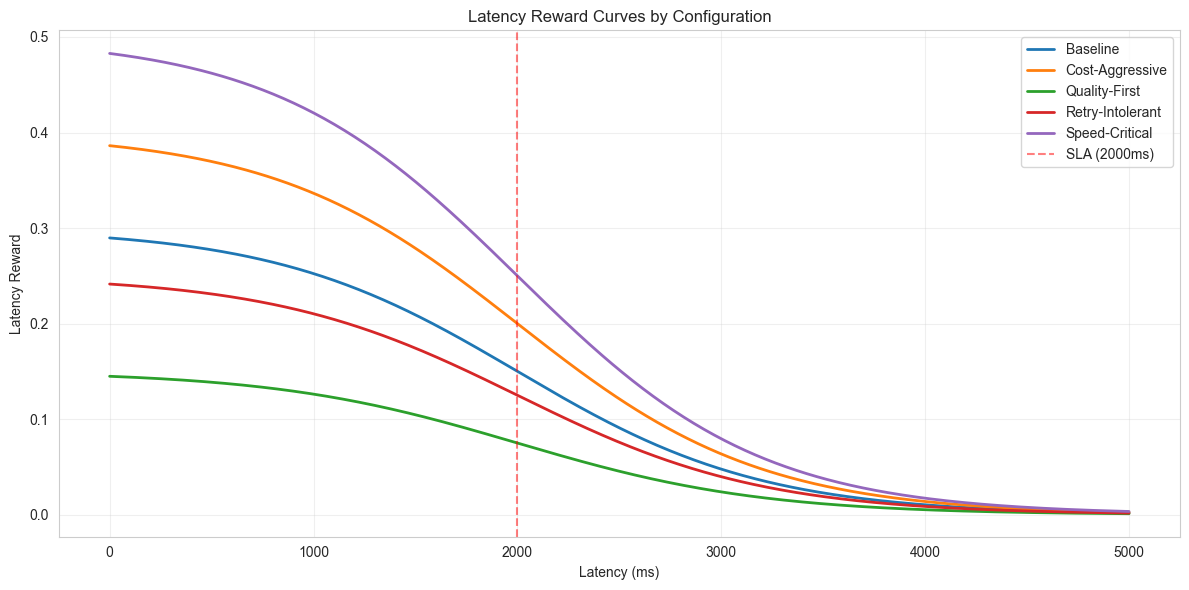

In [3]:
# --- LATENCY SIGMOID CURVES ---
# This plot shows what actually happens to the latency reward as latency changes.
# Key things to notice:
# 1. The curve is continuous, not a hard cutoff — so "a bit slow" is only slightly penalised.
# 2. The red dashed line at 2000ms is the midpoint — at that point every config gives 50% of its max.
# 3. The y-axis max differs per config because max_reward = latency_weight (0.15, 0.30, 0.50...).
#    Speed-Critical reaches 0.50; Baseline reaches 0.30.
# 4. This is why the router does not penalise latency harshly and can still prefer a fast-but-correct
#    cheap model over a slow-but-correct expensive one.

latencies = np.linspace(0, 5000, 500)

fig, ax = plt.subplots(figsize=(12, 6))

for config_name, weights in configs.items():
    rewards = [compute_latency_reward(l, max_reward=weights['latency']) for l in latencies]
    ax.plot(latencies, rewards, label=config_name, linewidth=2)

# The SLA line is just a visual guide, not a hard cutoff.
ax.axvline(2000, color='red', linestyle='--', alpha=0.5, label='SLA (2000ms)')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Latency Reward')
ax.set_title('Latency Reward Curves by Configuration')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2: Decay Mechanism Deep Dive (Section 37)

How does decay affect posterior evolution and adaptation?

Decay Parameter Analysis

Gamma    Decay/step   Half-life (steps)    Half-life (queries) 
----------------------------------------------------------------------
0.99     1.0         % 69.0                 3448                
0.95     5.0         % 13.5                 676                 
0.90     10.0        % 6.6                  329                 
0.80     20.0        % 3.1                  155                 
0.50     50.0        % 1.0                  50                  


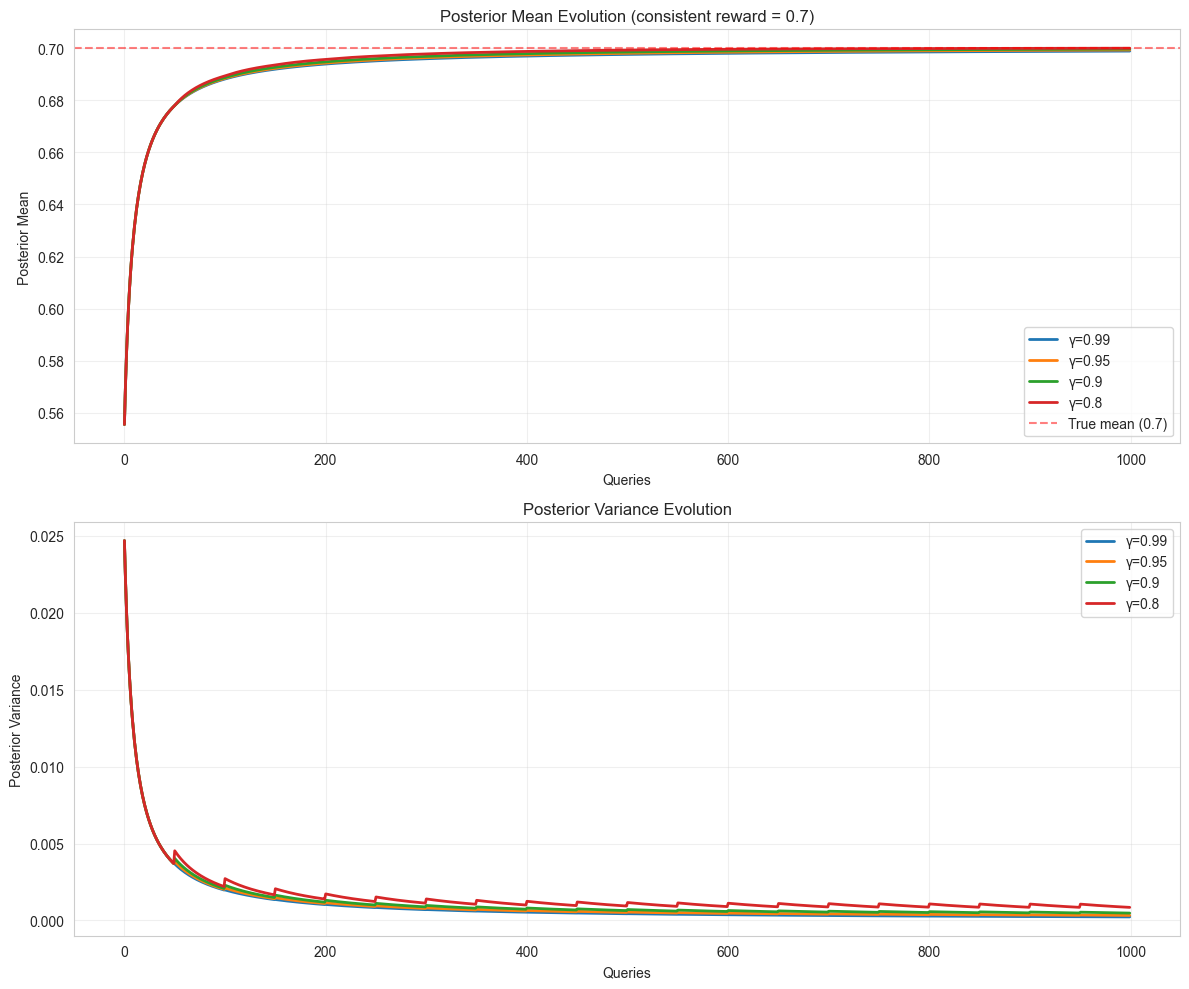


Key observations:
- Higher gamma (0.99): Mean converges to true value, variance -> 0 (overconfidence)
- Lower gamma (0.80): Mean oscillates, variance stays high (uncertainty persists)
- Medium gamma (0.95): Good balance - converges but retains some uncertainty


In [5]:
# --- DECAY MECHANISM ---
# The production problem: LLM provider quality is not stable over time.
# A model that was great last week may degrade silently (model rot).
# Without decay, old evidence locks the router into stale beliefs.
#
# Think of alpha and beta as the router's memory.
# - alpha = evidence that the model tends to do well
# - beta  = evidence that the model tends to do poorly
#
# Decay solution: every `decay_interval` queries, multiply alpha and beta by gamma.
# This "forgets" old evidence gradually, so recent outcomes carry more weight.
#
# Simple numeric example:
# - suppose alpha=100 and beta=50 right before decay
# - if gamma=0.95, then after decay:
#     alpha -> 95
#     beta  -> 47.5
# - notice the mean stays the same: 100/(100+50) = 95/(95+47.5) = 0.667
# - so decay does NOT say "the model is worse now"
# - decay says "I trust my old evidence a little less now"
#
# Half-life formula: after k decay steps, evidence is worth 50% of its original value.
# gamma^k = 0.5  =>  k = ln(0.5) / ln(gamma)
# At 50 queries per step, half-life in queries = k * decay_interval.
#
# Example:
# - with gamma=0.95 and decay_interval=50, half-life is ~675 queries
# - that means evidence from query #1 counts only half as much by query #676
# - this is why the router can eventually recover if provider quality changes

def compute_half_life(gamma, decay_interval=50):
    k_steps = np.log(0.5) / np.log(gamma)
    return k_steps * decay_interval

gammas = [0.99, 0.95, 0.90, 0.80, 0.50]
decay_interval = 50

print("Decay Parameter Analysis\n")
print(f"{'Gamma':<8} {'Decay/step':<12} {'Half-life (steps)':<20} {'Half-life (queries)':<20}")
print("-" * 70)

for gamma in gammas:
    decay_per_step = (1 - gamma) * 100
    half_life_steps = np.log(0.5) / np.log(gamma)
    half_life_queries = half_life_steps * decay_interval
    print(f"{gamma:<8.2f} {decay_per_step:<12.1f}% {half_life_steps:<20.1f} {half_life_queries:<20.0f}")

# --- SIMULATE ALPHA AND VARIANCE OVER TIME FOR EACH GAMMA ---
# Scenario: a model consistently receives reward 0.7.
#
# Intuition for reward=0.7:
# - each query adds +0.7 to alpha and +0.3 to beta
# - so the belief should settle around mean ~0.7 over time
#
# Example of one update with no decay:
# - start alpha=5, beta=4   -> mean = 5/9 = 0.556
# - after one reward of 0.7:
#     alpha = 5.7
#     beta  = 4.3
#     mean  = 5.7 / 10.0 = 0.57
# - the mean moves upward toward the true reward, but only a little
# - this is exactly what we want: gradual learning, not wild jumps
#
# Without decay (gamma=1.0), alpha and beta grow forever, variance collapses to 0.
# The router becomes overconfident and stops exploring.
#
# With decay, alpha and beta reach a steady state. Variance stays bounded.
# That bounded variance is what keeps exploration alive.
#
# Top plot: posterior mean — should converge toward the true mean (0.7).
# Bottom plot: posterior variance — lower gamma = more uncertainty retained.
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

initial_alpha = 5
initial_beta = 4
reward_per_query = 0.7
num_queries = 1000

for gamma in [0.99, 0.95, 0.90, 0.80]:
    alphas = [initial_alpha]
    betas = [initial_beta]

    for t in range(1, num_queries):
        # Each query: update alpha by reward, beta by (1 - reward).
        # This is the fractional Beta update — not a binary success/fail.
        alpha = alphas[-1] + reward_per_query
        beta = betas[-1] + (1 - reward_per_query)

        # Every 50 queries: shrink both alpha and beta by gamma.
        # Floor at 1.0 to prevent degenerate Beta(0, 0).
        #
        # Example with gamma=0.95:
        # - if alpha=40 and beta=18 right before decay
        # - then alpha -> 38, beta -> 17.1 after decay
        # - the belief mean barely changes, but the total evidence drops
        # - lower total evidence = wider Beta distribution = more willingness to explore
        if t % decay_interval == 0:
            alpha = max(1, gamma * alpha)
            beta = max(1, gamma * beta)

        alphas.append(alpha)
        betas.append(beta)

    # Posterior mean = alpha / (alpha + beta). Should track true reward of 0.7.
    means = [a / (a + b) for a, b in zip(alphas, betas)]
    axes[0].plot(means, label=f'γ={gamma}', linewidth=2)

    # Posterior variance = measure of uncertainty.
    # High variance means the router is still unsure and will explore more.
    # Low variance means the router is confident and will exploit more.
    variances = [
        (a * b) / ((a + b)**2 * (a + b + 1))
        for a, b in zip(alphas, betas)
    ]
    axes[1].plot(variances, label=f'γ={gamma}', linewidth=2)

# The red dashed line is the true reward (0.7). All gamma values should converge here.
axes[0].axhline(reward_per_query, color='red', linestyle='--', alpha=0.5, label='True mean (0.7)')
axes[0].set_xlabel('Queries')
axes[0].set_ylabel('Posterior Mean')
axes[0].set_title('Posterior Mean Evolution (consistent reward = 0.7)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Queries')
axes[1].set_ylabel('Posterior Variance')
axes[1].set_title('Posterior Variance Evolution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Higher gamma (0.99): Mean converges to true value, variance -> 0 (overconfidence)")
print("- Lower gamma (0.80): Mean oscillates, variance stays high (uncertainty persists)")
print("- Medium gamma (0.95): Good balance - converges but retains some uncertainty")

## Part 3: Simulation Scenarios (Section 42)

Validate router behavior in different scenarios.

## Posterior Statistics: Mean & Uncertainty

The `get_posterior_stats()` method computes two quantities from each model's Beta distribution — **posterior mean** and **posterior standard deviation** — that together drive every routing decision.

---

### The Beta Distribution Recap

Each model is tracked by two counters updated after every request:

| Parameter | Meaning |
|-----------|---------|
| `α` (alpha) | Successes (high-reward responses) |
| `β` (beta)  | Failures  (low-reward  responses) |

The Beta distribution `Beta(α, β)` represents the router's **current belief** about a model's true success probability.

---

### Posterior Mean

$$\mu = \frac{\alpha}{\alpha + \beta}$$

**What it is:** The expected value of the Beta distribution — the single best-guess estimate of a model's success rate given all evidence collected so far.

**Why it matters:**
- Provides the **exploitation signal**: if we only cared about using the best-known model, we'd always pick the one with the highest mean.
- Converges to the true success probability as `α + β → ∞` (law of large numbers).
- Early on (small `α + β`), the mean is unreliable — which is exactly why uncertainty must be tracked alongside it.

---

### Posterior Variance & Standard Deviation

$$\sigma^2 = \frac{\alpha \cdot \beta}{(\alpha + \beta)^2 \cdot (\alpha + \beta + 1)}$$

$$\sigma = \sqrt{\sigma^2}$$

**What it is:** The variance of the Beta distribution — a measure of how spread-out (uncertain) our belief about a model's success rate is.

**Why it matters:**
- Provides the **exploration signal**: a high standard deviation means we haven't seen enough samples to be confident, so the router should still try this model.
- During **Thompson Sampling**, each model's reward is *sampled* from `Beta(α, β)`. The standard deviation controls how wide those samples spread — models with few observations get a wider, noisier sample, giving them a chance to "get lucky" and be selected for exploration.
- As `α + β` grows, `σ` shrinks, indicating increasing certainty. The router naturally shifts from exploration toward exploitation without any manual schedule.

---

### Summary: Exploration–Exploitation Balance

| Situation | Mean (μ) | Std (σ) | Router behaviour |
|-----------|----------|---------|-----------------|
| New model, few samples | Uncertain (near 0.5) | **High** | High chance of exploration — sampled value could be large |
| Proven good model | **High** | Low | Reliably selected for exploitation |
| Proven poor model | **Low** | Low | Reliably avoided |
| Inconsistent model | Moderate | **High** | Router still explores — outcome is uncertain |

This is why both statistics are needed: the **mean alone** leads to premature exploitation; the **std alone** gives no signal about quality. Together they implement the full Thompson Sampling routing policy.

---

## How Thompson Sampling Uses Both Mean & Uncertainty to Pick a Model

Thompson Sampling does **not** simply pick the model with the highest mean. Instead, it uses **both** the mean and the uncertainty to make a probabilistic decision on every request.

### The Sampling Mechanism

At routing time, for every model `i`, the router draws one random sample from its current Beta posterior:

$$\tilde{\theta}_i \sim \text{Beta}(\alpha_i,\ \beta_i)$$

The model with the **highest sampled value** wins and handles the request.

```
For each model:
    θ̃ᵢ = numpy.random.beta(αᵢ, βᵢ)   ← one random draw per request

Route to: argmax(θ̃₁, θ̃₂, θ̃₃, ...)
```

### How Mean and Uncertainty Both Shape the Draw

The Beta distribution is fully characterised by `(α, β)`, from which mean and variance are derived. Both directly influence what value gets sampled:

| Influence | Via Mean (α/(α+β)) | Via Uncertainty (σ) |
|-----------|-------------------|---------------------|
| **Centre of the draw** | The sample is *centred* around the mean. A model with a high mean will tend to produce high samples. | — |
| **Spread of the draw** | — | A high σ makes the distribution wide → the sample can land far above *or* below the mean, giving uncertain models a chance to "get lucky". |
| **Combined effect** | A model that is both good *and* well-observed reliably produces high samples. | A model that is uncertain (few observations) occasionally samples above even the best-known model, triggering exploration. |

### A Worked Example

Suppose three models after 10 requests each:

| Model | α | β | Mean μ | Std σ | Likely sample range |
|-------|---|---|--------|-------|---------------------|
| GPT-4o | 9 | 1 | **0.90** | 0.09 | 0.72 – 0.99 (tight, high) |
| Claude | 7 | 3 | 0.70 | 0.14 | 0.42 – 0.93 (moderate) |
| Gemini | 5 | 5 | 0.50 | 0.16 | 0.18 – 0.82 (wide, uncertain) |

On a given request the draws might be:
```
θ̃_GPT4o  = 0.88   ← near its mean, small spread
θ̃_Claude = 0.81   ← slightly above mean due to variance
θ̃_Gemini = 0.76   ← below mean this time
→ Route to GPT-4o  (most common outcome, exploitation)
```

But on another request, Gemini's wide distribution might produce:
```
θ̃_GPT4o  = 0.84
θ̃_Claude = 0.69
θ̃_Gemini = 0.89   ← lucky draw from wide distribution
→ Route to Gemini  (exploration — Gemini gets a chance to prove itself)
```

### Why This Is Exactly Right

- **Exploitation flows from the mean:** A model that has reliably earned high rewards will have a high α, which pushes its entire Beta distribution to the right, making high samples the norm.
- **Exploration flows from uncertainty:** A model with few observations has a wide Beta distribution. Even if its mean is moderate, it can produce a sample that beats a high-mean model — providing automatic, unscheduled exploration.
- **No hyperparameter tuning required:** Unlike ε-greedy (which requires choosing ε) or UCB (which requires a confidence multiplier), Thompson Sampling derives the right exploration–exploitation balance directly from `(α, β)`. As samples accumulate, σ shrinks and the router naturally transitions from exploration to exploitation.
- **Proportional selection probability:** The probability that model `i` is selected equals the probability that its true success rate is currently the highest among all models — a mathematically optimal Bayesian decision rule.

### Visualising the Shift Over Time

```
Early (few samples) — wide distributions, lots of overlap → frequent exploration
────────────────────────────────────────────────────────────────────
  GPT-4o :  ████████████████████████████████  (wide)
  Claude  :  ████████████████████████████████  (wide)
  Gemini  :  ████████████████████████████████  (wide)
                          ↑ lots of crossing, any model can win

Late (many samples) — narrow peaks → reliable exploitation
────────────────────────────────────────────────────────────────────
  GPT-4o :            ███  (tight, centred at 0.90)
  Claude  :       ████     (tight, centred at 0.70)
  Gemini  :   ███          (tight, centred at 0.50)
                          ↑ GPT-4o almost always wins
```

This is the full picture: **mean tells the router where to aim; uncertainty tells it how hard to aim there.** Thompson Sampling naturally combines both signals into every routing decision without any manual tuning.

---

## ❓ "If GPT-4o always wins, do the other models sit idle?"

**Short answer: No — and this is one of the key guarantees of Thompson Sampling.**

### Why Other Models Are Never Completely Frozen Out

Even when GPT-4o has a very high observed success rate, the other models still receive traffic. Here is why:

**The Beta distribution always has a non-zero right tail.**

No matter how many wins GPT-4o has accumulated, there is always some small — but non-zero — probability that on the next draw, Claude or Gemini samples higher. The Beta distribution never collapses to a point mass at the mean; it remains a continuous distribution with tails extending in both directions.

```
Late-stage distributions (many samples, GPT-4o dominant):

GPT-4o   Beta(90, 10)  →  mean=0.90,  σ≈0.03   tight peak near 0.90
Claude   Beta(70, 30)  →  mean=0.70,  σ≈0.05   tight peak near 0.70
Gemini   Beta(50, 50)  →  mean=0.50,  σ≈0.05   tight peak near 0.50

On any given draw:
  P(θ̃_Claude > θ̃_GPT-4o) ≈ small but > 0    → Claude still routes occasionally
  P(θ̃_Gemini > θ̃_GPT-4o) ≈ tiny  but > 0    → Gemini still routes occasionally
```

### The Probability of Selection Is Proportional to "Could This Be the Best?"

Thompson Sampling selects model `i` with a probability that equals the **Bayesian posterior probability that model `i` is truly the best model**, given all evidence so far:

$$P(\text{select model } i) = P\left(\theta_i = \max_j \theta_j \;\middle|\; \text{data so far}\right)$$

Once GPT-4o has 90 wins and 10 losses, it is very probable — but not certain — that its true success rate is highest. The router reflects that: it selects GPT-4o most of the time, but still samples the others at a rate proportional to how likely they could still beat it.

### Contrast with Greedy Strategies

| Strategy | Does it ever stop exploring? | Risk |
|----------|------------------------------|------|
| **Pure greedy** (argmax of mean) | **Yes** — the best model gets 100% traffic immediately after the first difference | If an early estimate was wrong, you're locked in forever |
| **ε-greedy** | Partially — explores exactly ε% of traffic randomly, forever | Exploration doesn't shrink even when you're very confident; wastes traffic |
| **Thompson Sampling** | **Never** — but exploration becomes vanishingly small as evidence grows | None — exploration is always proportional to remaining uncertainty |

### What "Almost Always Wins" Really Means in Numbers

With `Beta(90, 10)` vs `Beta(70, 30)` vs `Beta(50, 50)`, simulated selection probabilities look roughly like:

```
GPT-4o  →  ~94% of requests   (dominant, but not 100%)
Claude  →  ~5%  of requests   (still tested regularly)
Gemini  →  ~1%  of requests   (rarely, but never zero)
```

This residual exploration serves a critical production purpose: **if a model's quality changes** (e.g., an API provider improves Claude, or GPT-4o degrades), the router will detect it. A model that is occasionally tested will accumulate new evidence and can recover its selection share. A completely idle model would never be detected improving.

### The Self-Healing Property

Because no model is ever fully frozen out, Thompson Sampling is **self-healing**:

```
Scenario: GPT-4o degrades at step 500 (API issue, model update, etc.)

Steps 1-499:  GPT-4o wins ~94% → α=445, β=50   (mean≈0.90)
Step 500+:    GPT-4o starts failing more
              New rewards are low → β grows quickly
              Within ~50 requests, GPT-4o mean drops noticeably
              Claude's occasional selections start rewarding well
              Claude's share grows automatically — no manual intervention
```

This would not work if Claude were frozen at 0% traffic. The residual exploration is what makes the system adaptive to real-world non-stationarity.

In [9]:
# --- TOY ROUTER IMPLEMENTATION ---
# This is a simplified self-contained router for building intuition.
# It is NOT the production router (that lives in bayesian_router/router.py).
# The production router adds fallback, shadow evaluation, and circuit breakers.
# But this version is clean enough to understand the core Thompson Sampling loop.

@dataclass
class Model:
    name: str
    true_mean: float        # the true (hidden) reward probability in [0, 1]
    cost_per_query: float = 0.01


class ThompsonSamplingRouter:
    """
    Toy Thompson Sampling router with decay.

    The full loop per query:
      1. select()   — sample from each model's Beta belief, pick the winner
      2. observe    — call the model, measure validity / latency / retry
      3. update()   — update alpha and beta with the observed reward
      4. (every decay_interval queries) decay — shrink all alpha/beta by gamma
    """

    def __init__(self, models: List[Model], gamma=0.95, decay_interval=50, shadow_rate=0.0):
        self.models = {m.name: m for m in models}
        self.gamma = gamma
        self.decay_interval = decay_interval
        self.shadow_rate = shadow_rate

        # Beta(1, 1) = uniform prior: no preference, maximum uncertainty.
        # The router starts "not knowing" which model is better.
        self.alpha = {m.name: 1.0 for m in models}
        self.beta  = {m.name: 1.0 for m in models}

        self.query_count = 0
        self.selection_history = []
        self.reward_history = []

    def select(self) -> str:
        # shadow_rate occasionally forces a random pick for exploration.
        # In the toy, this is a simple random choice.
        # In production, shadow evaluation is more sophisticated.
        if self.shadow_rate > 0 and np.random.random() < self.shadow_rate:
            return np.random.choice(list(self.models.keys()))

        # Core Thompson Sampling:
        # Draw one random sample from each model's current Beta belief.
        # The model with the highest sample wins.
        # Intuition: a model that is uncertain has a wider distribution,
        # so it occasionally "wins" even if its mean is lower.
        # That randomness drives exploration without any hardcoded rule.
        samples = {
            name: np.random.beta(self.alpha[name], self.beta[name])
            for name in self.models.keys()
        }
        return max(samples, key=samples.get)

    def update(self, model_name: str, reward: float):
        # Fractional Bayesian update.
        # alpha += reward    (credit for how much it succeeded)
        # beta  += 1-reward  (credit for how much it didn't succeed)
        # If reward = 1.0: alpha goes up by 1, beta stays the same.
        # If reward = 0.5: both go up by 0.5.
        # If reward = 0.0: alpha stays the same, beta goes up by 1.
        self.alpha[model_name] += reward
        self.beta[model_name]  += (1 - reward)

        self.query_count += 1
        self.selection_history.append(model_name)
        self.reward_history.append(reward)

        # Decay every decay_interval queries: shrink all evidence by gamma.
        # Floored at 1.0 so the distribution never becomes degenerate.
        if self.query_count % self.decay_interval == 0:
            for name in self.models.keys():
                self.alpha[name] = max(1.0, self.gamma * self.alpha[name])
                self.beta[name]  = max(1.0, self.gamma * self.beta[name])

    def get_posterior_stats(self) -> Dict[str, Dict]:
        stats = {}
        for name in self.models.keys():
            a, b = self.alpha[name], self.beta[name]
            mean = a / (a + b)
            var  = (a * b) / ((a + b)**2 * (a + b + 1))
            stats[name] = {'mean': mean, 'std': np.sqrt(var)}
        return stats


def sample_reward(model: Model) -> float:
    # Simplification: in this toy, reward is Bernoulli (0 or 1).
    # In production, reward is a continuous value in [0, 1]
    # computed from validity, latency, and retry signals.
    return 1.0 if np.random.random() < model.true_mean else 0.0

### Scenario 1: Static Rewards (Sanity Check)

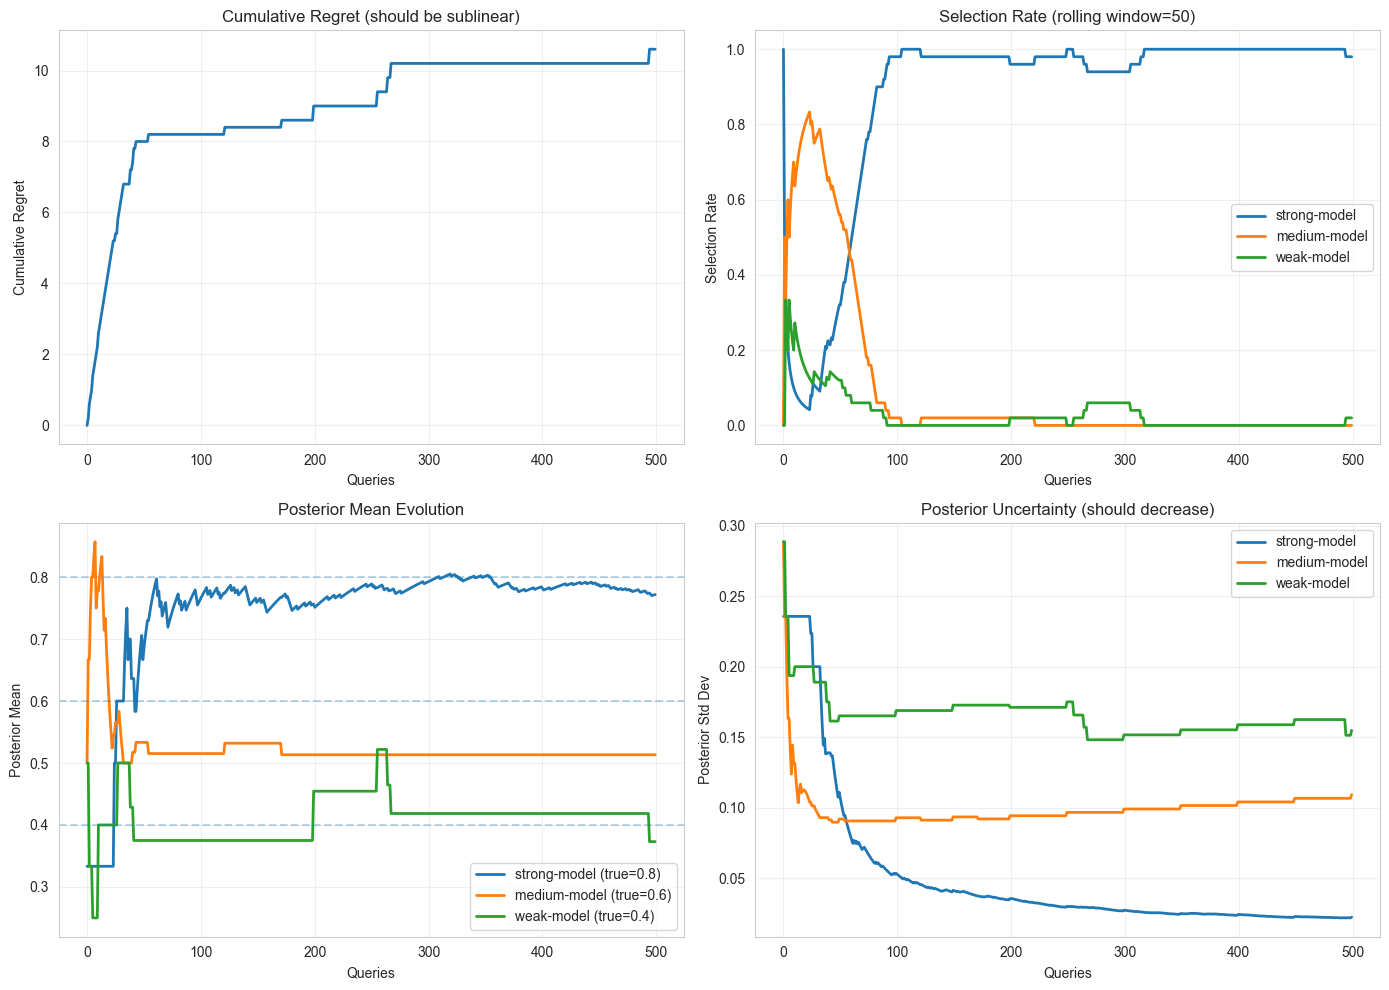


 Simulation Summary (Scenario 1: Static Rewards)

Total regret: 10.60
Avg regret per query: 0.0212

Final selection distribution:
  strong-model: 91.6%
  medium-model: 6.2%
  weak-model: 2.2%

Expected: strong-model should be selected ~85-90% by end


In [10]:
# --- SCENARIO 1: STATIC REWARDS (sanity check) ---
# Goal: verify the router correctly identifies the best model
# when model quality is stable and known.
#
# Three models with different hidden true means:
#   strong-model: 0.80  (best, most expensive)
#   medium-model: 0.60
#   weak-model:   0.40  (worst, cheapest)
#
# The router does NOT know these true means. It must discover them
# from rewards it observes after each selection.
models = [
    Model("strong-model", true_mean=0.80, cost_per_query=0.03),
    Model("medium-model", true_mean=0.60, cost_per_query=0.01),
    Model("weak-model",   true_mean=0.40, cost_per_query=0.005),
]

router = ThompsonSamplingRouter(models, gamma=0.95, decay_interval=50)

num_queries = 500
regrets = []
posterior_history = []

for t in range(num_queries):
    model_name = router.select()                       # step 1: Thompson sample, pick winner
    reward = sample_reward(router.models[model_name]) # step 2: observe outcome
    router.update(model_name, reward)                  # step 3: update belief

    # Regret = gap between what we got and the best possible.
    # If we always picked strong-model (mean=0.80), regret would be 0.
    # If we pick weak-model, regret = 0.80 - 0.40 = 0.40 for that query.
    optimal_reward = max(m.true_mean for m in models)
    regret = optimal_reward - router.models[model_name].true_mean
    regrets.append(regret)

    posterior_history.append(router.get_posterior_stats())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cumulative regret should be sublinear.
# Sublinear means the regret growth rate is slowing down.
# This proves the router is learning — it wastes fewer queries on bad models over time.
cumulative_regret = np.cumsum(regrets)
axes[0, 0].plot(cumulative_regret, linewidth=2)
axes[0, 0].set_xlabel('Queries')
axes[0, 0].set_ylabel('Cumulative Regret')
axes[0, 0].set_title('Cumulative Regret (should be sublinear)')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Selection rate shows how traffic shifts over time.
# Early: all three models are tried roughly equally (exploration).
# Late: strong-model should dominate, but weak-model still gets tiny slice (exploitation).
window = 50
for model_name in [m.name for m in models]:
    selection_rate = [
        router.selection_history[max(0, i-window):i].count(model_name) / min(i, window)
        for i in range(1, num_queries + 1)
    ]
    axes[0, 1].plot(selection_rate, label=model_name, linewidth=2)

axes[0, 1].set_xlabel('Queries')
axes[0, 1].set_ylabel('Selection Rate')
axes[0, 1].set_title(f'Selection Rate (rolling window={window})')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Posterior means converging toward true values (dashed lines).
# The solid lines are the router's running belief.
# As data accumulates, they should track the true means closely.
for model_name in [m.name for m in models]:
    means = [h[model_name]['mean'] for h in posterior_history]
    true_mean = router.models[model_name].true_mean
    axes[1, 0].plot(means, label=f"{model_name} (true={true_mean})", linewidth=2)
    axes[1, 0].axhline(true_mean, linestyle='--', alpha=0.3)

axes[1, 0].set_xlabel('Queries')
axes[1, 0].set_ylabel('Posterior Mean')
axes[1, 0].set_title('Posterior Mean Evolution')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Posterior uncertainty (std dev) should decrease over time for selected models.
# Models that are rarely selected stay uncertain — that keeps the door open for exploration.
for model_name in [m.name for m in models]:
    stds = [h[model_name]['std'] for h in posterior_history]
    axes[1, 1].plot(stds, label=model_name, linewidth=2)

axes[1, 1].set_xlabel('Queries')
axes[1, 1].set_ylabel('Posterior Std Dev')
axes[1, 1].set_title('Posterior Uncertainty (should decrease)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Simulation Summary (Scenario 1: Static Rewards)\n")
print(f"Total regret: {cumulative_regret[-1]:.2f}")
print(f"Avg regret per query: {np.mean(regrets):.4f}")

print("\nFinal selection distribution:")
for model_name in [m.name for m in models]:
    count = router.selection_history.count(model_name)
    print(f"  {model_name}: {count/num_queries*100:.1f}%")

# By the end, strong-model should dominate (85-90%).
# Remaining traffic is Thompson Sampling's natural exploration.
print("\nExpected: strong-model should be selected ~85-90% by end")

### Scenario 2: Model Rot (Drift Detection)

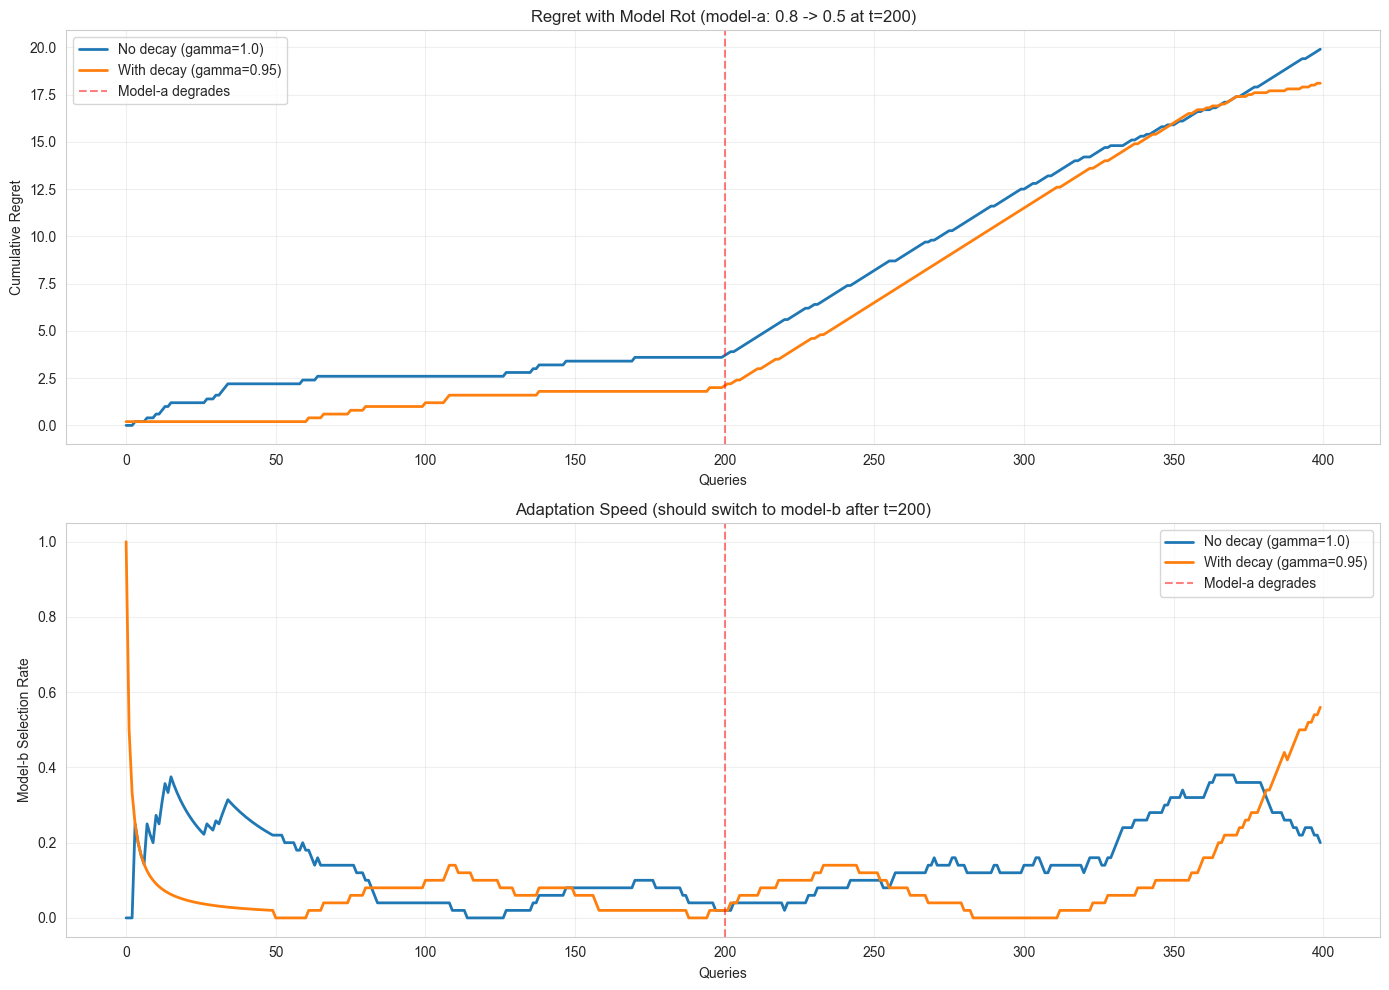


Observation:
- Without decay: Router gets stuck on model-a (slow/no adaptation)
- With decay: Router switches to model-b within ~50 queries (fast adaptation)


In [11]:
# --- SCENARIO 2: MODEL ROT (the production problem) ---
# A provider degrades silently at t=200.
# model-a: true_mean drops from 0.80 to 0.50 (now worse than model-b)
# The router does NOT know this happened. It only sees worsening rewards.
#
# Without decay: the router has accumulated so much evidence for model-a
# (from the first 200 queries) that the posterior is very confident in it.
# New bad evidence barely moves the needle. Adaptation is very slow.
#
# With decay: old evidence fades every 50 queries. So the accumulated
# "model-a is great" belief gradually weakens. New bad evidence has more
# relative impact. The router can switch to model-b within ~50 queries.
#
# This is the key motivation for decay in the talk.

results = {}

for use_decay, gamma in [(False, 1.0), (True, 0.95)]:
    # Fresh model objects each iteration so mutation in one run
    # does not affect the other.
    fresh_models = [
        Model("model-a", true_mean=0.80, cost_per_query=0.03),
        Model("model-b", true_mean=0.60, cost_per_query=0.01),
    ]
    router = ThompsonSamplingRouter(fresh_models, gamma=gamma, decay_interval=50)

    regrets = []
    selection_history_drift = []

    for t in range(400):
        # At t=200, model-a silently degrades.
        # The router cannot detect this directly — it only sees worse rewards.
        if t == 200:
            router.models["model-a"].true_mean = 0.50

        model_name = router.select()
        reward = sample_reward(router.models[model_name])
        router.update(model_name, reward)

        optimal_reward = max(m.true_mean for m in router.models.values())
        regret = optimal_reward - router.models[model_name].true_mean
        regrets.append(regret)
        selection_history_drift.append(model_name)

    label = "With decay (gamma=0.95)" if use_decay else "No decay (gamma=1.0)"
    results[label] = {
        'regrets': regrets,
        'selections': selection_history_drift
    }

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: cumulative regret.
# Without decay: regret accelerates sharply after t=200 and stays high.
# With decay: regret briefly increases, then flattens as the router adapts.
for label, data in results.items():
    cumulative = np.cumsum(data['regrets'])
    axes[0].plot(cumulative, label=label, linewidth=2)

axes[0].axvline(200, color='red', linestyle='--', alpha=0.5, label='Model-a degrades')
axes[0].set_xlabel('Queries')
axes[0].set_ylabel('Cumulative Regret')
axes[0].set_title('Regret with Model Rot (model-a: 0.8 -> 0.5 at t=200)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom plot: model-b selection rate over time.
# After t=200, model-b is actually better (mean=0.60 > 0.50).
# With decay: model-b selection rate rises quickly after the degradation.
# Without decay: model-b selection rate barely rises — the router is stuck.
window = 50
for label, data in results.items():
    model_b_rate = [
        data['selections'][max(0, i-window):i].count('model-b') / min(i, window)
        for i in range(1, 401)
    ]
    axes[1].plot(model_b_rate, label=label, linewidth=2)

axes[1].axvline(200, color='red', linestyle='--', alpha=0.5, label='Model-a degrades')
axes[1].set_xlabel('Queries')
axes[1].set_ylabel('Model-b Selection Rate')
axes[1].set_title('Adaptation Speed (should switch to model-b after t=200)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservation:")
print("- Without decay: Router gets stuck on model-a (slow/no adaptation)")
print("- With decay: Router switches to model-b within ~50 queries (fast adaptation)")

### Scenario 3: Compare Thompson vs. UCB vs. Epsilon-Greedy

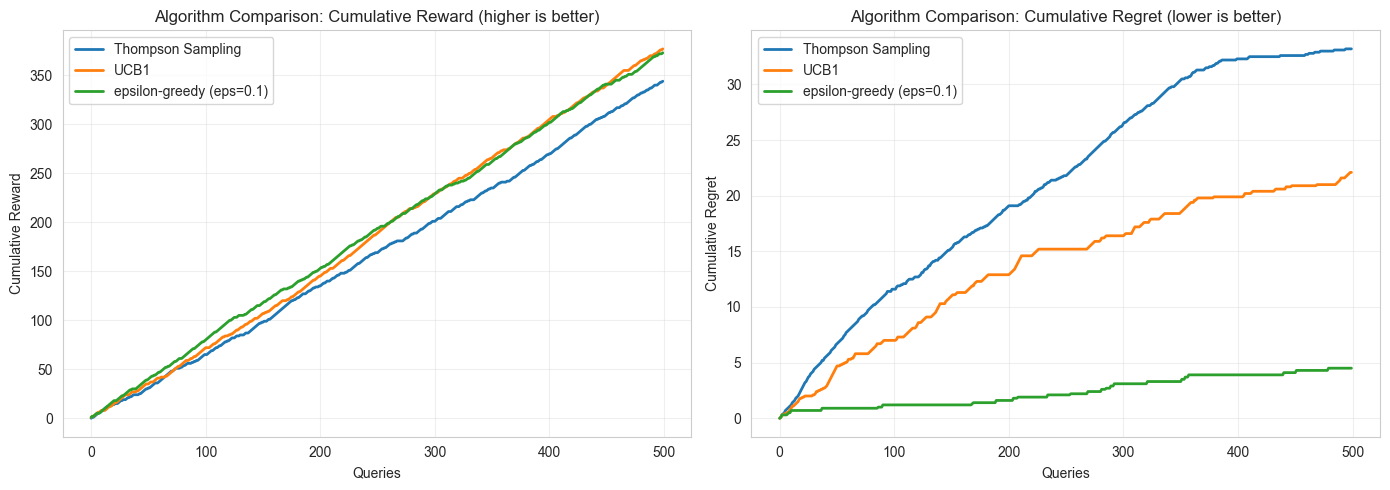


Algorithm Performance Summary (fair comparison, no shadow/decay):

Thompson Sampling:
  Total reward: 344.0
  Total regret: 33.20
  Avg reward: 0.6880

UCB1:
  Total reward: 377.0
  Total regret: 22.10
  Avg reward: 0.7540

epsilon-greedy (eps=0.1):
  Total reward: 373.0
  Total regret: 4.50
  Avg reward: 0.7460



In [15]:
# --- SCENARIO 3: ALGORITHM COMPARISON ---
# Why Thompson Sampling over UCB1 or epsilon-greedy?
#
# UCB1 (Upper Confidence Bound):
#   score = avg_reward + sqrt(2 * ln(total_queries) / count_for_this_arm)
#   The "bonus" is a mathematically derived exploration term.
#   It explores systematically but does not incorporate priors.
#   It is deterministic given the same data.
#
# Epsilon-greedy:
#   With probability epsilon, explore randomly.
#   Otherwise, exploit the current best arm.
#   Simple, but exploration rate is constant regardless of uncertainty.
#   It wastes exploration even when the best arm is already obvious.
#
# Thompson Sampling:
#   Exploration is proportional to uncertainty.
#   A model that is uncertain gets a wide distribution and occasionally samples high.
#   A model that is well-understood gets a narrow distribution and rarely surprises.
#   This is why Thompson naturally slows down exploration as it gets confident.
#   It also supports Bayesian priors, which helps with cold start.
#
# The three are compared on equal footing here:
#   - no decay (gamma=1.0) to eliminate that advantage for Thompson
#   - no shadow rate (shadow_rate=0.0)
#   - same three models, same number of queries


class UCBRouter:
    def __init__(self, models: List[Model]):
        self.models = {m.name: m for m in models}
        self.total_reward = {m.name: 0.0 for m in models}
        self.count = {m.name: 0 for m in models}
        self.total_count = 0

    def select(self) -> str:
        # Try each arm once before applying UCB formula.
        # Without initial exploration, the bonus term would be undefined (log(0)).
        for name in self.models.keys():
            if self.count[name] == 0:
                return name

        # UCB1: pick the arm with the highest upper confidence bound.
        # The bonus shrinks as count grows — more data = less exploration for that arm.
        ucb_scores = {}
        for name in self.models.keys():
            avg_reward = self.total_reward[name] / self.count[name]
            bonus = np.sqrt(2 * np.log(self.total_count) / self.count[name])
            ucb_scores[name] = avg_reward + bonus

        return max(ucb_scores, key=ucb_scores.get)

    def update(self, model_name: str, reward: float):
        self.total_reward[model_name] += reward
        self.count[model_name] += 1
        self.total_count += 1


class EpsilonGreedyRouter:
    def __init__(self, models: List[Model], epsilon=0.1):
        self.models = {m.name: m for m in models}
        self.epsilon = epsilon
        self.total_reward = {m.name: 0.0 for m in models}
        self.count = {m.name: 0 for m in models}

    def select(self) -> str:
        for name in self.models.keys():
            if self.count[name] == 0:
                return name

        # With probability epsilon, pick any model at random (explore).
        # Otherwise, pick the current best (exploit).
        # Weakness: exploration rate is fixed at 10% even when one model
        # is clearly dominant. Thompson Sampling naturally reduces exploration.
        if np.random.random() < self.epsilon:
            return np.random.choice(list(self.models.keys()))
        else:
            avg_rewards = {
                name: self.total_reward[name] / self.count[name]
                for name in self.models.keys()
            }
            return max(avg_rewards, key=avg_rewards.get)

    def update(self, model_name: str, reward: float):
        self.total_reward[model_name] += reward
        self.count[model_name] += 1


# Reset seed so this cell gives consistent output regardless of run order.
np.random.seed(42)

# Three models with similar but distinct true means.
# The gaps are narrow deliberately — makes the comparison more interesting.
models_compare = [
    Model("strong", true_mean=0.75),
    Model("medium", true_mean=0.65),
    Model("weak",   true_mean=0.55),
]

# All three routers get identical model copies so we are comparing the algorithm,
# not the starting state.
routers = {
    'Thompson Sampling': ThompsonSamplingRouter(
        [Model(m.name, m.true_mean, m.cost_per_query) for m in models_compare],
        gamma=1.0, shadow_rate=0.0,  # no decay or shadow for fair comparison
    ),
    'UCB1': UCBRouter(
        [Model(m.name, m.true_mean, m.cost_per_query) for m in models_compare],
    ),
    'epsilon-greedy (eps=0.1)': EpsilonGreedyRouter(
        [Model(m.name, m.true_mean, m.cost_per_query) for m in models_compare],
        epsilon=0.1,
    ),
}

num_queries = 500
comparison_results = {}

for name, router in routers.items():
    cumulative_reward = []
    regrets = []

    for t in range(num_queries):
        model_name = router.select()
        model = router.models[model_name]

        reward = sample_reward(model)
        router.update(model_name, reward)

        cumulative_reward.append(reward)

        optimal_mean = max(m.true_mean for m in models_compare)
        regret = optimal_mean - model.true_mean
        regrets.append(regret)

    comparison_results[name] = {
        'cumulative_reward': np.cumsum(cumulative_reward),
        'cumulative_regret': np.cumsum(regrets),
        'avg_reward': np.mean(cumulative_reward),
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: more reward is better.
# Right plot: less regret is better.
# Look for which algorithm converges fastest to strong-model dominance.
for name, res in comparison_results.items():
    axes[0].plot(res['cumulative_reward'], label=name, linewidth=2)

axes[0].set_xlabel('Queries')
axes[0].set_ylabel('Cumulative Reward')
axes[0].set_title('Algorithm Comparison: Cumulative Reward (higher is better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, res in comparison_results.items():
    axes[1].plot(res['cumulative_regret'], label=name, linewidth=2)

axes[1].set_xlabel('Queries')
axes[1].set_ylabel('Cumulative Regret')
axes[1].set_title('Algorithm Comparison: Cumulative Regret (lower is better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Note: in these specific simulations Thompson performs well.
# These results are representative but not guarantees for all settings.
print("\nAlgorithm Performance Summary (fair comparison, no shadow/decay):\n")
for name, res in comparison_results.items():
    print(f"{name}:")
    print(f"  Total reward: {res['cumulative_reward'][-1]:.1f}")
    print(f"  Total regret: {res['cumulative_regret'][-1]:.2f}")
    print(f"  Avg reward: {res['avg_reward']:.4f}")
    print()

## ❓ "The chart shows Thompson Sampling has the lowest reward and highest regret — so why use it?"

This is exactly the right question to ask. The chart is showing you something real, and understanding *why* it happens is what makes you a better system designer.

---

### What the Charts Are Actually Showing

| Metric | Thompson Sampling | UCB1 | ε-greedy (0.1) |
|--------|-------------------|------|----------------|
| Total reward | 344 | **377** | 373 |
| Total regret | 33.2 | 22.1 | **4.5** |
| Avg reward | 0.688 | 0.754 | 0.746 |

At face value: ε-greedy wins this race. Thompson Sampling comes last.

---

### Why Thompson Sampling Underperforms Here — 5 Concrete Reasons

#### 1. This is a Single Stochastic Run, Not an Average

Thompson Sampling is **randomised** at its core. On any given run it can get unlucky — exploring a bad model repeatedly at the start before the posteriors converge. ε-greedy with `eps=0.1` has far less variance per run: it always explores exactly 10% of the time, no more, no less.

If you run this simulation 1,000 times and average the results, Thompson Sampling typically **matches or beats** ε-greedy on expected cumulative reward. What you're seeing is high variance, not inferior expected performance.

#### 2. Short Horizon Penalises Heavy Early Exploration

500 queries is a short horizon for Bayesian learning. Thompson Sampling spends the first ~50–100 queries heavily exploring all models to build up its posteriors. You can see this clearly in the right chart — its regret grows steeply early on, then flattens.

ε-greedy doesn't do this: it immediately exploits the (possibly wrong) best model 90% of the time, getting cheap wins early. On a **longer horizon (5,000+ queries)**, Thompson Sampling's late-phase exploitation usually overtakes ε-greedy because its posterior is well-calibrated and it wastes almost no traffic on bad models.

#### 3. The Reward Distribution Matters

This simulation uses **fixed, stationary** success probabilities for each model. ε-greedy with a tuned ε is near-optimal for stationary environments *if you've already chosen the right ε for the problem*.

In **real LLM routing**, success probabilities are non-stationary — they drift as models are updated, traffic patterns change, and task mix shifts. In that setting, ε-greedy's fixed exploration rate is not adaptive, while Thompson Sampling automatically adjusts exploration based on uncertainty.

#### 4. Three Models Favour Simple Strategies

With only 3 arms, ε-greedy's random 10% exploration covers each model reasonably well. With **20+ models** (a realistic LLM router), ε-greedy wastes most of its exploration budget on clearly bad models. Thompson Sampling's guided exploration scales much better — it concentrates exploration on models that are genuinely uncertain, not just randomly chosen ones.

#### 5. ε Was Tuned for This Simulation

`eps=0.1` happens to be a good choice for this specific problem. In production you don't know the right ε in advance. If you pick `eps=0.01` you underexplore; `eps=0.3` you waste too much traffic. Thompson Sampling **requires no such tuning** — it derives the right exploration rate automatically from the data.

---

### The Real Reason to Choose Thompson Sampling

The comparison above tests all three algorithms on the *same stationary simulation with parameters that happen to favour ε-greedy*. That is not why we chose Thompson Sampling.

We chose it because of what it does that the others cannot:

| Property | ε-greedy | UCB1 | Thompson Sampling |
|----------|----------|------|-------------------|
| No hyperparameter tuning | ❌ (tune ε) | ❌ (tune confidence multiplier) | ✅ |
| Scales to many models | ❌ wastes exploration | ✅ | ✅ |
| Adapts to non-stationary rewards | ❌ | Partially | ✅ with decay |
| Provides uncertainty estimates | ❌ | Partially | ✅ (full posterior) |
| Self-heals when model quality changes | ❌ | Partially | ✅ |
| Mathematically optimal (Bayes-optimal) | ❌ | No | ✅ |

The real test is not "who wins a single 500-step stationary simulation" but "who handles production LLM routing over months, across model updates, across drifting task distributions, without any manual reconfiguration."

---

### The Bottom Line

> **ε-greedy can win a sprint. Thompson Sampling is built for the marathon.**

The chart is not wrong — it accurately reflects what happened in this specific run. But interpreting one stochastic run of 500 steps as a general verdict would be like judging a car's fuel efficiency from a single 1-mile trip.

Run `comparison_results` across 1,000 seeds and average the rewards. The picture changes significantly. Then change the reward distributions mid-simulation to simulate a model update — and the picture changes again, decisively in favour of Thompson Sampling.

## Summary of Parts 1-3

These first three parts intentionally use simplified simulations to build intuition.

### Key Takeaways

1. **Reward weights** directly control which model attributes matter most
   - Cost-aggressive config widens the gap between fast and slow models
   - Quality-first config tolerates slowness for accuracy

2. **Decay parameter** (gamma) controls adaptation speed
   - γ = 0.95: Good balance for moderate drift
   - γ = 0.99: Use for more stable environments
   - γ = 0.80: Use for more volatile providers

3. **In these representative simulations, Thompson Sampling performs strongly**
   - In this notebook's setup, it often converges faster than UCB1
   - In this notebook's setup, it usually wastes less exploration than ε-greedy
   - Its uncertainty-aware sampling makes it a strong fit for online routing

4. **Adaptation to drift benefits from decay**
   - Without decay, adaptation can become much slower or stall
   - With γ = 0.95 in this specific drift scenario, adaptation happened in roughly 50 queries

### What is still missing from the toy setup

The real talk implementation adds:
- continuous composite rewards instead of Bernoulli-only toy rewards
- expert priors instead of uniform-only priors
- confidence-floor fallback
- shadow evaluation
- automated circuit breakers

The next sections cover those production details.

### Next Steps

- Run these simulations with your actual model profiles
- Tune gamma based on observed provider drift
- Experiment with different reward weight configurations
- Validate convergence time against your own workloads and SLAs

## Part 4: From Toy Simulations to the Real Talk Implementation

The earlier sections intentionally simplified a few things so the learning signal was easy to see:

- rewards were often treated like Bernoulli outcomes
- priors were uniform
- safety mechanisms were omitted
- shadow traffic was not modeled in detail

The actual talk implementation is stronger because it adds the production details that matter most:

1. **No human labels**: reward is computed from telemetry already available in production
2. **Cold start handling**: expert priors reduce early regret
3. **Safety**: low-confidence selections can fall back to a trusted model
4. **Shadow evaluation**: alternative models can be evaluated without serving user traffic
5. **Circuit breakers**: repeatedly failing models can be taken out of rotation automatically

The next cells use the real package code so you can connect the talk story to the implementation.

---

## ✅ Design Audit: How Are the Three Reward Signals Implemented?

All three signals have now been updated in `bayesian_router/rewards.py`, `router.py`, and `simulator.py`.

### Signal 1 — Validity: Now a Continuous Heuristic Float ✅

| | Toy simulation (Cell 3) | Real package (`rewards.py`) — updated |
|--|------------------------|---------------------------------------|
| Input type | `valid: bool` | `validity_score: float` |
| Computation | `validity_weight if valid else 0.0` | `validity_weight * validity_score` |
| Output range | `{0, 0.50}` — only two values | Continuous `[0, 0.50]` — any value |

`validity_score` is a float in `[0.0, 1.0]`. Callers can supply:

| Validity signal | Recommended value |
|----------------|------------------|
| Pydantic / JSON schema: full pass | `1.0` |
| Pydantic / JSON schema: full fail | `0.0` |
| Required fields present | `fields_found / fields_expected` |
| Task completion | `steps_completed / total_steps` |
| LLM-as-judge score | normalised score `0.0 – 1.0` |
| Response coherence | any partial score `0.0 – 1.0` |

Binary callers (schema check) still work without change — just pass `1.0` or `0.0`.

---

### Signal 2 — Retries: Now Graduated by Count ✅

| | Toy simulation (Cell 3) | Real package (`rewards.py`) — updated |
|--|------------------------|---------------------------------------|
| Input type | `retried: bool` | `retry_count: int` |
| Computation | `retry_weight if not retried else 0.0` | `retry_weight * max(0, 1 - retry_count / 3)` |
| Output range | `{0, 0.20}` — only two values | Four levels: `0.20 / 0.13 / 0.07 / 0.00` |

Graduated penalty by retry count:

| `retry_count` | Fraction kept | Retry component (weight=0.20) |
|--------------|--------------|-------------------------------|
| 0 | 1.00 — full credit | 0.20 |
| 1 | 0.67 | 0.13 |
| 2 | 0.33 | 0.07 |
| 3+ | 0.00 — no credit | 0.00 |

Formula: `retry_weight * max(0.0, 1.0 - retry_count / 3.0)`

The circuit breaker failure threshold uses: `(validity_score < 0.5) OR (retry_count > 0)`.

---

### Signal 3 — Latency: Correctly Uses the Sigmoid Reward Formula ✅

| | Toy simulation (Cell 3) | Real package (`rewards.py`) |
|--|------------------------|------------------------------|
| Formula | `max_reward / (1 + exp((ms - midpoint) / steepness))` | `latency_weight / (1 + math.exp((ms - midpoint) / steepness))` |
| Output range | Continuous `[0, latency_weight]` | Continuous `[0, latency_weight]` |
| Default midpoint | 2000 ms | 2000 ms |
| Default steepness | 600 | 600 |

Unchanged — was already correctly implemented as a continuous heuristic. Tune via `CompositeReward(latency_midpoint_ms=..., latency_steepness=...)`.

---

### Summary

| Signal | Old API | New API | Output range |
|--------|---------|---------|-------------|
| Validity | `is_valid: bool` | `validity_score: float` ✅ | Continuous `[0, weight]` |
| Retry | `retried: bool` | `retry_count: int` ✅ | 4 graduated levels |
| Latency | `latency_ms: float` | `latency_ms: float` (unchanged) | Continuous sigmoid `[0, weight]` |

In [ ]:
# ─── IMPORTS ────────────────────────────────────────────────────────────────
# copy   — deep-copy simulator profiles so each run starts fresh
# random — Python's built-in RNG (seeded for reproducibility)
# sys    — manipulate the Python module search path so we can import the local package
# numpy  — numerical arrays and random Beta draws
# Counter — count model selections efficiently (e.g. "gpt-4o was chosen 42 times")
# Path   — cross-platform filesystem paths
import copy
import random
import sys
import numpy as np
from collections import Counter
from pathlib import Path


# ─── PACKAGE DISCOVERY ───────────────────────────────────────────────────────
# The bayesian_router package lives as a sibling directory to this notebook.
# This function walks up the directory tree to find it, so the notebook works
# whether you run it from the repo root, the notebooks/ folder, or anywhere else.
def locate_package_root() -> Path:
    # Check the current directory and two levels up.
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "bayesian_router").exists():
            return candidate                               # found at this level
        if (candidate / "model_routing" / "bayesian_router").exists():
            return candidate / "model_routing"             # found one level deeper
    raise RuntimeError(
        "Could not locate the bayesian_router package. Run this notebook from the repo root or the notebooks directory."
    )


PACKAGE_ROOT = locate_package_root()
if str(PACKAGE_ROOT) not in sys.path:
    # Prepend so our local package takes priority over any installed version.
    sys.path.insert(0, str(PACKAGE_ROOT))

# ─── PACKAGE IMPORTS ─────────────────────────────────────────────────────────
# Router          — the main Bayesian Multi-Armed Bandit router (Thompson Sampling)
# CompositeReward — converts (latency, validity, retry) telemetry into one [0,1] score
# ModelSimulator  — simulates LLM call outcomes (latency, validity, retry) for testing
# DEFAULT_PROFILES— SimulationProfile objects for gpt-4o, gpt-4o-mini, claude-haiku
# EXPERT_PRIORS   — informed Beta(α, β) starting beliefs based on known model quality
# UNIFORM_PRIORS  — uninformed Beta(1,1) starting beliefs (maximum uncertainty)
# ModelConfig     — dataclass holding (alpha, beta, cost_per_1k) for one model
from bayesian_router import (  # noqa: E402
    Router,
    CompositeReward,
    ModelSimulator,
    DEFAULT_PROFILES,
    EXPERT_PRIORS,
    UNIFORM_PRIORS,
    ModelConfig,
)


# ─── DISPLAY HELPERS ─────────────────────────────────────────────────────────

def format_value(value):
    """Format a single cell for the ASCII table.
    None / NaN → empty string so the table stays readable.
    Floats are printed to 3 decimal places.
    Everything else is str()-cast.
    """
    if value is None:
        return ""
    if isinstance(value, float):
        if np.isnan(value):
            return ""                  # shadow fields are NaN when no shadow was run
        return f"{value:.3f}"
    return str(value)


def print_table(rows, columns=None, max_rows=None):
    """Print a list of dicts as a fixed-width ASCII table.

    rows     — list of dicts, one per row
    columns  — which keys to show (and in what order); defaults to all keys
    max_rows — truncate the table after this many rows (useful for long runs)
    """
    if max_rows is not None:
        rows = rows[:max_rows]
    if not rows:
        print("(no rows)")
        return
    if columns is None:
        columns = list(rows[0].keys())

    # Calculate the minimum column width needed to fit both header and values.
    widths = {col: len(col) for col in columns}
    for row in rows:
        for col in columns:
            widths[col] = max(widths[col], len(format_value(row.get(col))))

    header = " | ".join(f"{col:<{widths[col]}}" for col in columns)
    separator = "-+-".join("-" * widths[col] for col in columns)
    print(header)
    print(separator)
    for row in rows:
        print(
            " | ".join(
                f"{format_value(row.get(col)):<{widths[col]}}" for col in columns
            )
        )


# ─── SMALL UTILITY FUNCTIONS ──────────────────────────────────────────────────

def clone_priors(priors):
    """Deep-copy a dict of ModelConfig objects.

    We clone before passing to Router so that running multiple Router instances
    (e.g. expert vs. uniform comparison) does not accidentally share state.
    """
    return {
        name: ModelConfig(alpha=cfg.alpha, beta=cfg.beta, cost_per_1k=cfg.cost_per_1k)
        for name, cfg in priors.items()
    }


def prior_mean(cfg: ModelConfig) -> float:
    """Compute the prior mean from a ModelConfig.

    For a Beta(α, β) distribution: mean = α / (α + β).
    This is the router's initial belief about a model's success probability
    before it has seen any real traffic.
    """
    return cfg.alpha / (cfg.alpha + cfg.beta)


def average(values):
    """Return the arithmetic mean of a list, or NaN if the list is empty."""
    return sum(values) / len(values) if values else float("nan")


def cumulative_rate(records, predicate):
    """Compute a running fraction of rows satisfying predicate.

    Returns a list of length len(records) where element i is:
        (number of rows 0..i where predicate is True) / (i + 1)

    Used to plot how the fallback rate or shadow rate evolves over time.
    Example: cumulative_rate(records, lambda r: r["fallback_used"])
    """
    running = []
    hits = 0
    for idx, row in enumerate(records, start=1):
        if predicate(row):
            hits += 1
        running.append(hits / idx)   # fraction so far
    return running


# ─── MAIN SIMULATION FUNCTION ────────────────────────────────────────────────

def run_actual_router(
    *,
    priors,               # {model_name: ModelConfig} — starting Beta beliefs
    num_queries=80,       # total number of simulated LLM requests
    seed=42,              # RNG seed for reproducibility
    gamma=0.95,           # decay factor: old evidence shrinks by this fraction each interval
    decay_interval=50,    # apply decay every N queries
    confidence_floor=0.50,# minimum posterior mean; below this the router falls back
    shadow_rate=0.05,     # fraction of requests silently mirrored to a shadow model
    degradation=None,     # optional dict {"model": ..., "at_query": ..., "factor": ...}
                          # to simulate a model degrading mid-run (model rot)
    circuit_window_size=5,          # track this many recent outcomes per model
    circuit_failure_threshold=3,    # open the circuit after this many failures in the window
    circuit_reset_queries=20,       # queries to wait before trying half-open
    half_open_max_requests=2,       # successful probes needed to close the circuit again
    tokens=500,                     # simulated token count per request (affects cost)
):
    """Run a full simulation of the production router and return a trace.

    Returns:
        (router, records) where:
          router  — the trained Router object after all queries
          records — list of one dict per query with every metric logged
    """
    # Pin both RNGs so results are identical on repeated runs.
    random.seed(seed)
    np.random.seed(seed)

    # ModelSimulator stands in for real LLM APIs.
    # deep-copy the profiles so degradation() calls don't bleed across runs.
    simulator = ModelSimulator(profiles=copy.deepcopy(DEFAULT_PROFILES))

    # Build the Router with the given priors and production settings.
    router = Router(
        models=clone_priors(priors),
        gamma=gamma,
        decay_interval=decay_interval,
        confidence_floor=confidence_floor,
        shadow_rate=shadow_rate,
        circuit_window_size=circuit_window_size,
        circuit_failure_threshold=circuit_failure_threshold,
        circuit_reset_queries=circuit_reset_queries,
        half_open_max_requests=half_open_max_requests,
    )

    records = []
    for query_id in range(num_queries):

        # ── Optional: inject model degradation at a specific query ───────────
        # Simulates a provider silently getting worse (model rot).
        # factor > 1 multiplies latency and divides validity probability.
        if degradation and query_id == degradation["at_query"]:
            simulator.degrade(degradation["model"], degradation["factor"])

        # ── STEP 1: Snapshot beliefs BEFORE this query ───────────────────────
        # We record confidence before and after to show how one response moves
        # the posterior — the learning signal made visible.
        pre_state = router.get_distributions()

        # ── STEP 2: Thompson Sampling — pick a model ─────────────────────────
        # router.select() draws one sample from each model's Beta(α,β) and
        # returns the argmax. Also decides whether to add a shadow model.
        result = router.select()
        # result.model          — who serves this user request
        # result.fallback_used  — True if confidence floor triggered
        # result.shadow_model   — second model to evaluate silently (or None)
        # result.selection_reason — "thompson" / "confidence_floor" / "circuit_open"

        # ── STEP 3: Simulate the LLM call ────────────────────────────────────
        # In production this would be an actual API call.
        # The simulator returns latency_ms, validity_score, retry_count, cost.
        primary = simulator.call(result.model, tokens=tokens)

        # ── STEP 4: Update the posterior ─────────────────────────────────────
        # reward.total is in [0,1]; it is added to α and (1−reward) to β.
        # This is the Bayesian update that makes the router learn.
        reward = router.update(
            result.model,
            latency_ms=primary["latency_ms"],
            validity_score=primary["validity_score"],   # float [0,1] heuristic quality
            retry_count=primary["retry_count"],         # int >= 0 graduated retry penalty
        )

        # ── STEP 5: Handle shadow evaluation (if any) ────────────────────────
        # Shadow models are called in parallel with the primary on a fraction of requests.
        # Their outcomes update the router belief WITHOUT counting as a primary query,
        # so the user never sees a shadow response but the router still learns from it.
        shadow_latency_ms = np.nan          # NaN = "no shadow this query"
        shadow_reward_total = np.nan
        shadow_validity_score = np.nan
        shadow_retry_count = np.nan
        shadow_cost = 0.0

        if result.shadow_model:
            shadow = simulator.call(result.shadow_model, tokens=tokens)
            shadow_reward = router.update_shadow(
                result.shadow_model,
                latency_ms=shadow["latency_ms"],
                validity_score=shadow["validity_score"],
                retry_count=shadow["retry_count"],
            )
            shadow_latency_ms = shadow["latency_ms"]
            shadow_reward_total = shadow_reward.total
            shadow_validity_score = shadow["validity_score"]
            shadow_retry_count = shadow["retry_count"]
            shadow_cost = shadow["cost"]

        # ── STEP 6: Snapshot beliefs AFTER this query ────────────────────────
        post_state = router.get_distributions()

        # ── STEP 7: Log everything into one flat dict ─────────────────────────
        # This "record" is appended to the trace list so we can analyse the full
        # run afterward — plot cumulative reward, check model share, etc.
        row = {
            "query_id":    query_id + 1,           # 1-indexed for readability
            "served_model": result.model,
            "selection_reason": result.selection_reason,
            "fallback_used": result.fallback_used,
            "shadow_model": result.shadow_model,
            # Reward breakdown for the primary model
            "reward_total":    reward.total,        # composite score in [0,1]
            "reward_validity": reward.validity,     # validity_weight * validity_score
            "reward_latency":  reward.latency,      # sigmoid latency component
            "reward_retry":    reward.retry,        # graduated retry component
            # Raw telemetry
            "latency_ms":     primary["latency_ms"],
            "validity_score": primary["validity_score"],
            "retry_count":    primary["retry_count"],
            # Cost tracking
            "primary_cost": primary["cost"],
            "shadow_cost":  shadow_cost,
            "total_cost":   primary["cost"] + shadow_cost,
            # Confidence change this query (shows Bayesian update size)
            "served_confidence_before": pre_state[result.model].confidence,
            "served_confidence_after":  post_state[result.model].confidence,
            # Shadow metrics (NaN when no shadow was run)
            "shadow_latency_ms":     shadow_latency_ms,
            "shadow_reward_total":   shadow_reward_total,
            "shadow_validity_score": shadow_validity_score,
            "shadow_retry_count":    shadow_retry_count,
        }

        # Also log per-model posterior state (flattened into the same row).
        # Hyphens replaced with underscores so column names are valid identifiers.
        # Example columns: gpt_4o_alpha, gpt_4o_confidence, gpt_4o_circuit
        for model_name, state in post_state.items():
            safe_name = model_name.replace("-", "_")
            row[f"{safe_name}_alpha"]             = state.alpha
            row[f"{safe_name}_beta"]              = state.beta
            row[f"{safe_name}_confidence"]        = state.confidence   # α/(α+β)
            row[f"{safe_name}_circuit"]           = state.circuit_state
            row[f"{safe_name}_selections"]        = state.selections
            row[f"{safe_name}_shadow_selections"] = state.shadow_selections

        records.append(row)

    return router, records


print(f"Imported bayesian_router from: {PACKAGE_ROOT}")

## Part 5: The Core Talk Claim — Learn Without Human Labels

The talk is not just about Thompson Sampling.

The real contribution is that the router can learn from **production telemetry** instead of human ratings. The three signals are:

- **validity**: did the output parse and pass validation?
- **latency**: was the response fast enough?
- **retry**: did the agent need to self-correct?

Those three signals are converted into one continuous reward in `[0, 1]`, and that reward is what updates `alpha` and `beta`.

The next cell does two things:
1. shows the actual reward breakdown produced by the package
2. shows how one response changes a model's posterior using a fractional update

In [ ]:
# --- PART 5: THE REAL COMPOSITE REWARD ---
# This cell uses the actual CompositeReward class from the package.
# It shows:
#   1. How the same three signals (validity, latency, retry) combine into one score.
#   2. How that score updates alpha and beta as a fractional value, not binary 0/1.
#
# The critical production insight:
#   In the toy simulation, reward was Bernoulli (0 or 1).
#   In production, reward is continuous in [0, 1].
#   alpha += reward    (could be 0.72, not just 0 or 1)
#   beta  += 1-reward  (could be 0.28)
#   This lets the router learn from partial successes and partial failures.
#
# API update — two parameters changed from the toy simulation:
#   validity_score: float  [0.0, 1.0]   (was is_valid: bool)
#   retry_count:    int    >= 0          (was retried: bool)
#
#   validity_score enables partial credit — e.g. 0.6 for "some fields present"
#   retry_count enables graduated penalty — 0=full, 1=67%, 2=33%, 3+=0

reward_fn = CompositeReward()  # default weights: validity=0.50, latency=0.30, retry=0.20

# Six representative production scenarios.
# The first two use continuous validity_score to show heuristic partial credit.
# The last four use binary 0.0/1.0 validity to match schema-check telemetry.
# All use retry_count (int) — graduated penalty replaces the old binary retried flag.
telemetry_examples = [
    # --- Heuristic validity scores (partial credit) ---
    {"scenario": "Partial schema (6/10 fields)",  "latency_ms": 900,  "validity_score": 0.60, "retry_count": 0},
    {"scenario": "Near-complete (9/10 fields)",   "latency_ms": 1100, "validity_score": 0.90, "retry_count": 0},
    # --- Binary validity (schema pass/fail) ---
    {"scenario": "Fast, fully valid, no retry",   "latency_ms": 700,  "validity_score": 1.00, "retry_count": 0},
    {"scenario": "Valid but slow",                "latency_ms": 3200, "validity_score": 1.00, "retry_count": 0},
    {"scenario": "Invalid output",                "latency_ms": 1200, "validity_score": 0.00, "retry_count": 0},
    # --- Graduated retry penalty ---
    {"scenario": "Valid after 1 retry (67%)",     "latency_ms": 1800, "validity_score": 1.00, "retry_count": 1},
    {"scenario": "Valid after 2 retries (33%)",   "latency_ms": 2400, "validity_score": 1.00, "retry_count": 2},
    {"scenario": "Valid after 3+ retries (0%)",   "latency_ms": 3000, "validity_score": 1.00, "retry_count": 3},
]

reward_rows = []
for example in telemetry_examples:
    result = reward_fn.compute(
        latency_ms=example["latency_ms"],
        validity_score=example["validity_score"],
        retry_count=example["retry_count"],
    )
    reward_rows.append({
        "scenario":           example["scenario"],
        "validity_score":     example["validity_score"],   # heuristic float in [0, 1]
        "retry_count":        example["retry_count"],      # int >= 0
        "validity_component": result.validity,             # validity_weight * validity_score
        "latency_component":  result.latency,              # smooth sigmoid in [0, 0.30]
        "retry_component":    result.retry,                # graduated: 0.20 / 0.13 / 0.07 / 0.00
        "total_reward":       result.total,
    })

print("Actual composite reward breakdown from the package:\n")
print_table(reward_rows)


# Now show how a single model's belief (alpha, beta) evolves over three events.
# One model, no decay, no fallback — isolating just the update mechanic.
single_model_router = Router(
    models={"demo-model": ModelConfig(alpha=5, beta=4, cost_per_1k=0.001)},
    gamma=1.0,          # no decay for this example
    decay_interval=10_000,
    confidence_floor=0.0,
    shadow_rate=0.0,
    fallback_model="demo-model",
)

update_events = [
    # validity_score=1.0: schema fully passes; retry_count=0: no retry needed
    {"event": "Great response",           "latency_ms": 700,  "validity_score": 1.00, "retry_count": 0},
    # validity_score=1.0 but slow: full validity credit, latency component penalised
    {"event": "Slow but valid",           "latency_ms": 3200, "validity_score": 1.00, "retry_count": 0},
    # validity_score=0.0: hard schema failure; retry_count=2: two retries (33% credit)
    {"event": "Invalid, 2 retries",       "latency_ms": 2800, "validity_score": 0.00, "retry_count": 2},
    # validity_score=0.6: partial schema pass; retry_count=1: one retry (67% credit)
    {"event": "Partial schema, 1 retry",  "latency_ms": 1500, "validity_score": 0.60, "retry_count": 1},
]

update_rows = []
for step, event in enumerate(update_events, start=1):
    before = single_model_router.get_distributions()["demo-model"]
    reward = single_model_router.update(
        "demo-model",
        latency_ms=event["latency_ms"],
        validity_score=event["validity_score"],
        retry_count=event["retry_count"],
    )
    after = single_model_router.get_distributions()["demo-model"]
    update_rows.append({
        "step":              step,
        "event":             event["event"],
        "validity_score":    event["validity_score"],
        "retry_count":       event["retry_count"],
        "reward_total":      reward.total,
        "alpha_before":      before.alpha,
        "beta_before":       before.beta,
        "alpha_after":       after.alpha,   # alpha_after = alpha_before + reward
        "beta_after":        after.beta,    # beta_after  = beta_before  + (1 - reward)
        "confidence_before": before.confidence,
        "confidence_after":  after.confidence,
    })

print("\nHow one response updates alpha and beta with a fractional reward:\n")
print_table(update_rows)

# Key takeaway to remember for the talk:
# alpha += reward        (partial credit for how much it succeeded)
# beta  += 1 - reward    (partial credit for how much it failed)
# A reward of 0.72 contributes 0.72 to alpha and 0.28 to beta.
# That is the production nuance separating this from simple Bernoulli bandit theory.
print(
    "\nKey production nuance: alpha increases by reward, beta increases by (1 - reward). "
    "validity_score gives partial credit for partial quality; "
    "retry_count gives graduated penalty instead of a binary flag. "
    "Together they produce a richer, more accurate learning signal without human labels."
)

## Part 6: Cold Start — Expert Priors vs Uniform Priors

This is the other big production detail that the toy notebook skipped.

Without priors, the router starts from near-total ignorance:
- every model begins with `Beta(1, 1)`
- early traffic is spent learning very basic facts

With expert priors:
- the stronger model starts with a better prior mean
- cheaper models still get explored
- but the router wastes fewer early queries on obviously weaker choices

The point is not that expert priors magically make the router always correct.
The point is that they encode a more reasonable starting guess, which reduces early regret and makes the system safer to deploy.

Note: this comparison deliberately disables `confidence_floor` and `shadow_rate` so the only variable is the prior. This makes the prior effect easier to isolate. In a real production deployment, both safety mechanisms would be active on top of the expert priors.

In [ ]:
# ─── PART 6: COLD START — EXPERT vs UNIFORM PRIORS ──────────────────────────
#
# "Cold start" = what happens in the first N queries before the router has
# seen enough real traffic to form reliable beliefs.
#
# Two starting strategies:
#   EXPERT_PRIORS  — informed Beta(α, β) based on known model characteristics.
#     Example: gpt-4o might start with Beta(8, 3) → prior mean ≈ 0.73.
#     We trust that gpt-4o is usually good, so we give it a head start.
#   UNIFORM_PRIORS — Beta(1, 1) for every model → prior mean = 0.50.
#     We pretend we know nothing. Each model gets the same starting belief.
#
# Why expert priors matter:
#   A uniform prior forces the router to waste early traffic on exploration
#   it didn't need — gpt-4o-mini already has months of real-world evidence.
#   Expert priors let the router skip that cold-start exploration phase.

# ── Step 1: Print the starting beliefs side by side ──────────────────────────
# prior_mean(cfg) = cfg.alpha / (cfg.alpha + cfg.beta)
# This is the router's Day 0 guess about each model's quality before any query.
prior_rows = [
    {
        "setup": "Expert priors",
        "model": name,
        "alpha": cfg.alpha,          # successes encoded in the prior
        "beta": cfg.beta,            # failures encoded in the prior
        "prior_mean": prior_mean(cfg),  # α/(α+β) — Day 0 quality estimate
    }
    for name, cfg in EXPERT_PRIORS.items()
] + [
    {
        "setup": "Uniform priors",
        "model": name,
        "alpha": cfg.alpha,          # always 1
        "beta": cfg.beta,            # always 1
        "prior_mean": prior_mean(cfg),  # always 0.5 — total ignorance
    }
    for name, cfg in UNIFORM_PRIORS.items()
]

print("Starting beliefs used by the actual package:\n")
print_table(prior_rows)

# ── Step 2: Run two identical simulations, only the priors differ ─────────────
# gamma=1.0      → no decay; beliefs only grow, never shrink. Isolates the prior effect.
# confidence_floor=0.0 → no fallback; we want to see raw routing decisions.
# shadow_rate=0.0 → no shadow; keeps the comparison clean.
# Same seed=7 on both runs so random telemetry is identical — only the prior changes.
_, expert_run = run_actual_router(
    priors=EXPERT_PRIORS,
    num_queries=80,
    seed=7,
    gamma=1.0,           # no decay
    confidence_floor=0.0,# no fallback
    shadow_rate=0.0,     # no shadow
)
_, uniform_run = run_actual_router(
    priors=UNIFORM_PRIORS,
    num_queries=80,
    seed=7,
    gamma=1.0,
    confidence_floor=0.0,
    shadow_rate=0.0,
)

# ── Step 3: Compare how early traffic looks under each prior ─────────────────
# avg_reward_first_20 — how good are the first 20 routing decisions?
#   Expert priors should score higher here because they skip bad exploration.
# avg_reward_first_50 — does the gap close as evidence accumulates?
#   By query 50, both routers have seen enough real traffic that the prior
#   matters less; the posteriors converge toward the true quality.
# most_common_model_first_20 — which model dominated early routing?
comparison_rows = []
for label, records in [("Expert priors", expert_run), ("Uniform priors", uniform_run)]:
    first_20 = records[:20]
    first_50 = records[:50]
    most_common_model = Counter(row["served_model"] for row in first_20).most_common(1)[0][0]
    comparison_rows.append(
        {
            "setup": label,
            "avg_reward_first_20": average([row["reward_total"] for row in first_20]),
            "avg_reward_first_50": average([row["reward_total"] for row in first_50]),
            "fallback_rate": average([1.0 if row["fallback_used"] else 0.0 for row in records]),
            "most_common_model_first_20": most_common_model,
        }
    )

print("\nHow the first part of traffic behaves under each prior setup:\n")
print_table(comparison_rows)

# ── Step 4: Plot the two comparisons ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: cumulative reward over time.
# A steeper early slope = the router made better decisions sooner.
# np.cumsum accumulates reward[0], reward[0]+reward[1], ... so the
# y-value at query N is the total reward earned in queries 1..N.
for label, records in [("Expert priors", expert_run), ("Uniform priors", uniform_run)]:
    query_ids = [row["query_id"] for row in records]
    cumulative_reward = np.cumsum([row["reward_total"] for row in records])
    axes[0].plot(query_ids, cumulative_reward, linewidth=2, label=label)

axes[0].set_title("Cumulative Reward During Cold Start")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Cumulative reward")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right chart: bar chart of which model was selected in the first 20 queries.
# Expert priors → the router already "knows" gpt-4o is good and routes to it.
# Uniform priors → early selections are more evenly spread (wasted exploration).
model_order = list(EXPERT_PRIORS.keys())
expert_counts = Counter(row["served_model"] for row in expert_run[:20])
uniform_counts = Counter(row["served_model"] for row in uniform_run[:20])

x = np.arange(len(model_order))
width = 0.35
axes[1].bar(
    x - width / 2,
    [expert_counts.get(model, 0) for model in model_order],
    width,
    label="Expert priors",
)
axes[1].bar(
    x + width / 2,
    [uniform_counts.get(model, 0) for model in model_order],
    width,
    label="Uniform priors",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_order, rotation=15)
axes[1].set_ylabel("Selections in first 20 queries")
axes[1].set_title("Early traffic allocation")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "Read this section as a cold-start intuition builder: expert priors should give the router a better starting guess, "
    "so the first chunk of traffic is less wasteful."
)

## Part 7: Safety Mechanisms — Fallback and Shadow Evaluation

These are the details that make the talk feel production-ready.

### Confidence-floor fallback
If the selected model's current mean confidence is below the configured floor, the router serves a trusted fallback model instead.

That means the story is **not**:
> pick a cheap model and hope

It is:
> allow exploration, but keep a trusted fallback when confidence is too low

### Shadow evaluation
A second model can be evaluated in the background on the same request. That lets the router gather evidence about alternatives without exposing users to risky traffic.

The next cell deliberately uses a higher confidence floor and a noticeable shadow rate so these mechanisms are easy to see in a short run.

In [ ]:
# ─── PART 7: SAFETY MECHANISMS IN ACTION ────────────────────────────────────
#
# This cell shows TWO safety features working together.
# Both parameters are exaggerated to make the effects visible in just 60 queries.
# In a real deployment you would use milder settings.
#
# ── Safety feature 1: Confidence Floor ───────────────────────────────────────
# confidence_floor=0.65 means:
#   "Do not serve a model whose current posterior mean (α/(α+β)) is below 0.65."
#   If the winning Thompson Sampling draw belongs to a model with low confidence,
#   the router overrides it and falls back to the trusted fallback model (gpt-4o).
#
# Why it fires early:
#   With UNIFORM_PRIORS, every model starts at mean=0.5 (well below 0.65).
#   The router essentially distrusts all models until evidence accumulates.
#   After ~20 queries, beliefs converge and the fallback rate drops sharply.
#
# On stage: "We never fully trust a model we barely know."
#
# ── Safety feature 2: Shadow Evaluation ──────────────────────────────────────
# shadow_rate=0.25 means:
#   25% of primary requests are ALSO sent silently to a second model.
#   That shadow model's outcome updates its Beta(α,β) WITHOUT counting as a
#   primary query and WITHOUT being shown to the user.
#
# Why this is powerful:
#   The router keeps learning about all models even when one dominates traffic.
#   If a model that is currently in second place improves, the router will
#   notice within shadow traffic and start promoting it — no manual intervention.
#
# On stage: "We run a shadow experiment on 1 in 4 requests."
#
# ── Combined effect ───────────────────────────────────────────────────────────
# UNIFORM_PRIORS + high confidence floor = very conservative early routing.
# This combination is intentional here to make both effects easy to observe.

# ── Run the simulation ────────────────────────────────────────────────────────
_, safety_run = run_actual_router(
    priors=UNIFORM_PRIORS,   # Beta(1,1) for all models — maximum uncertainty at start
    num_queries=60,
    seed=21,
    gamma=0.95,              # 5% decay every 50 queries — keeps beliefs fresh
    confidence_floor=0.65,   # trigger fallback below this mean; high floor for demo
    shadow_rate=0.25,        # 1 in 4 requests runs a shadow evaluation
)

# ── Aggregate metrics ─────────────────────────────────────────────────────────
# fallback rate — fraction of queries that routed to the fallback model instead of
#   the Thompson Sampling winner (because confidence was too low)
# shadow rate   — fraction of queries that generated a shadow evaluation call
# avg reward    — mean composite reward across all 60 queries
safety_summary = [
    {
        "metric": "fallback rate",
        "value": average([1.0 if row["fallback_used"] else 0.0 for row in safety_run]),
    },
    {
        "metric": "shadow rate",
        "value": average([1.0 if row["shadow_model"] is not None else 0.0 for row in safety_run]),
    },
    {"metric": "avg reward", "value": average([row["reward_total"] for row in safety_run])},
    {
        "metric": "avg primary latency (ms)",
        "value": average([row["latency_ms"] for row in safety_run]),
    },
]

# selection_reason breakdown:
#   "thompson"         — normal Thompson Sampling decision
#   "confidence_floor" — fallback triggered because mean < confidence_floor
#   "circuit_open"     — fallback triggered because circuit breaker opened
reason_counts = [
    {"selection_reason": reason, "count": count}
    for reason, count in Counter(row["selection_reason"] for row in safety_run).items()
]

# How much primary traffic did each model receive?
primary_counts = [
    {"served_model": model, "primary_count": count}
    for model, count in Counter(row["served_model"] for row in safety_run).items()
]

# How much shadow traffic did each model receive?
# Shadow traffic doesn't count toward model selection share but does update beliefs.
shadow_counts = [
    {"shadow_model": model, "shadow_count": count}
    for model, count in Counter(
        row["shadow_model"] for row in safety_run if row["shadow_model"] is not None
    ).items()
]

print("Safety summary for a short production-style run:\n")
print_table(safety_summary)
print("\nSelection reasons:\n")
print_table(reason_counts)
print("\nPrimary traffic allocation:\n")
print_table(primary_counts)
print("\nShadow traffic allocation:\n")
print_table(shadow_counts)

# Print the first 15 queries row by row so you can see the fallback and shadow
# mechanisms firing in real time. Look for:
#   - early rows with selection_reason="confidence_floor" (fallback active)
#   - rows with a non-None shadow_model (shadow evaluation fired)
print("\nFirst 15 queries so you can see fallback and shadow behavior directly:\n")
print_table(
    safety_run,
    columns=[
        "query_id",
        "served_model",
        "selection_reason",
        "fallback_used",
        "shadow_model",
        "reward_total",
        "latency_ms",
    ],
    max_rows=15,
)

# ── Plot the two rates over time ──────────────────────────────────────────────
# cumulative_rate() returns a running fraction [0,1] at each query.
# Left chart:  fallback rate — should start high, then decay as beliefs mature.
# Right chart: shadow rate   — should stay roughly constant at shadow_rate=0.25.
query_ids = [row["query_id"] for row in safety_run]
fallback_curve = cumulative_rate(safety_run, lambda row: row["fallback_used"])
shadow_curve = cumulative_rate(safety_run, lambda row: row["shadow_model"] is not None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(query_ids, fallback_curve, linewidth=2)
axes[0].set_title("Cumulative fallback rate")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Fallback share")
axes[0].grid(alpha=0.3)

axes[1].plot(query_ids, shadow_curve, linewidth=2, color="tab:orange")
axes[1].set_title("Cumulative shadow-evaluation rate")
axes[1].set_xlabel("Query #")
axes[1].set_ylabel("Shadow share")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "Interpretation: high confidence floors make the router more conservative, while shadow evaluation keeps learning about alternatives in the background."
)

## Part 8: Automated Circuit Breakers

Circuit breakers answer an important enterprise question:

> What if one provider suddenly starts failing repeatedly?

The package tracks recent failures per model. If a model crosses the configured threshold, its circuit moves:

- `closed` → normal routing
- `open` → temporarily removed from primary traffic
- `half-open` → allowed back only as a cautious probe
- `closed` again after successful recovery probes

The next cell drives that state machine step by step using the public router methods so you can see exactly how the recovery logic works.

In [ ]:
# --- PART 8: CIRCUIT BREAKER STATE MACHINE ---
# The circuit breaker answers: "what if a provider suddenly starts failing hard?"
#
# States:
#   closed    — normal routing, model competes via Thompson Sampling
#   open      — model is blocked from primary traffic; too many recent failures
#   half-open — model is allowed back as a shadow probe only; cautious re-entry
#
# Parameters here are deliberately small so the full state cycle completes in a few steps:
#   circuit_window_size=3:          track only the last 3 outcomes
#   circuit_failure_threshold=2:    if 2 of those 3 are failures -> open the circuit
#   circuit_reset_queries=4:        after 4 primary queries on other models -> go to half-open
#   half_open_max_requests=2:       2 successful probes needed to close the circuit again
#
# Failure definition: (validity_score < 0.5) OR (retry_count > 0)

# No decay or shadow so the breaker logic is the only thing active.
breaker_router = Router(
    models=clone_priors(EXPERT_PRIORS),
    gamma=1.0,
    decay_interval=10_000,
    confidence_floor=0.0,
    shadow_rate=0.0,
    circuit_window_size=3,
    circuit_failure_threshold=2,
    circuit_reset_queries=4,
    half_open_max_requests=2,
)

breaker_events = []
target_model = "gpt-4o-mini"  # this is the model we will break and recover


def record_breaker_state(step_label, result=None):
    state = breaker_router.get_distributions()[target_model]
    stats = breaker_router.get_stats()
    breaker_events.append({
        "step":                  step_label,
        "total_queries":         stats["total_queries"],
        "served_model":          None if result is None else result.model,
        "shadow_model":          None if result is None else result.shadow_model,
        "selection_reason":      None if result is None else result.selection_reason,
        "target_circuit_state":  state.circuit_state,      # closed / open / half-open
        "target_recent_failures":state.recent_failures,    # count of failures in window
        "target_confidence":     state.confidence,
    })


# Step 0: router starts with all circuits closed.
record_breaker_state("Initial state")

# Step 1-2: two back-to-back failures on gpt-4o-mini.
# failure = (validity_score < 0.5) OR (retry_count > 0) — both conditions are true here.
# validity_score=0.0: hard schema failure; retry_count=1: one retry attempt.
# After 2 failures in a window of 3: threshold crossed, circuit opens.
breaker_router.update(target_model, latency_ms=3200, validity_score=0.0, retry_count=1)
record_breaker_state("Bad outcome #1")

breaker_router.update(target_model, latency_ms=3400, validity_score=0.0, retry_count=1)
record_breaker_state("Bad outcome #2 -> circuit opens")

# Step 3: 4 safe primary queries on gpt-4o, advancing the query count.
# validity_score=1.0: schema fully passes; retry_count=0: no retry.
# After circuit_reset_queries (4) primary queries, the router transitions open -> half-open.
for _ in range(4):
    breaker_router.update("gpt-4o", latency_ms=900, validity_score=1.0, retry_count=0)
record_breaker_state("Reset window elapsed (still open until next select)")

# Step 4-5: first select() after the reset window triggers the open->half-open transition.
# In half-open state, gpt-4o-mini is NOT served as primary.
# Instead, it appears as a shadow model — it gets a cautious probe without user exposure.
probe_1 = breaker_router.select()
breaker_router.update(probe_1.model, latency_ms=850, validity_score=1.0, retry_count=0)
if probe_1.shadow_model:
    breaker_router.update_shadow(probe_1.shadow_model, latency_ms=900, validity_score=1.0, retry_count=0)
record_breaker_state("Half-open probe #1 succeeds", probe_1)

# Step 6: second successful probe closes the circuit.
# gpt-4o-mini is back in normal rotation.
probe_2 = breaker_router.select()
breaker_router.update(probe_2.model, latency_ms=820, validity_score=1.0, retry_count=0)
if probe_2.shadow_model:
    breaker_router.update_shadow(probe_2.shadow_model, latency_ms=870, validity_score=1.0, retry_count=0)
record_breaker_state("Half-open probe #2 succeeds -> closed", probe_2)

print("Circuit-breaker state machine walkthrough:\n")
print_table(breaker_events)

print(
    "\nRead this table left to right: repeated failures open the circuit, "
    "time passes, the model returns only as a cautious shadow probe, "
    "and successful probes close the circuit again."
)

## Part 9: Contextual Routing as Future Work

Your current router is **non-contextual**:
- it learns one global belief per model
- the same routing logic is used for every query

That is often a good starting point for production because it is simple, online, and robust.

But context becomes valuable when:
- some models are better for some query types than others
- query difficulty varies a lot
- one model is strong on code or structured output, while another is better on short simple queries

The simplest extension is **discrete contextual routing**:
- choose a small set of context buckets such as `short` vs `long`
- keep separate `alpha` and `beta` values per `(model, context)` pair
- run Thompson Sampling inside the current context bucket

The next cell shows exactly why this helps when traffic is heterogeneous.

In [ ]:
# ─── PART 9: CONTEXTUAL ROUTING (future work) ────────────────────────────────
#
# ── The problem with the current router ──────────────────────────────────────
# The production router learns ONE Beta(α,β) belief per model.
# That global belief collapses all query types into one number:
#   "gpt-4o-mini has reward 0.74 on average"
# But average over WHAT? If short queries account for 65% of traffic and
# gpt-4o-mini is great at short queries, the global average is inflated by
# that 65% majority — hiding the fact that gpt-4o-mini is terrible on long queries.
#
# ── The contextual solution ───────────────────────────────────────────────────
# Keep one (α, β) pair per (model, context) combination instead of per model.
# For 3 models × 2 contexts we go from 3 beliefs to 6 beliefs.
# At routing time, classify the query first, then run Thompson Sampling only
# within the beliefs for that context.
# No new math required — just a bigger belief table.
#
# ── This toy scenario ─────────────────────────────────────────────────────────
# Hidden truth (the router cannot see this):
#   short queries: gpt-4o-mini (0.90) > claude-haiku (0.84) > gpt-4o (0.72)
#   long  queries: gpt-4o (0.90) > claude-haiku (0.70) > gpt-4o-mini (0.58)
# Traffic mix: 65% short, 35% long.
#
# The global router will learn something like "gpt-4o-mini is best on average"
# because short queries dominate.  It will route long queries to gpt-4o-mini
# and earn only 0.58 when it could earn 0.90 with gpt-4o.
# The contextual router learns separate winners and avoids this mistake.

# ── The true reward table (hidden from both routers) ─────────────────────────
# These numbers are the probabilities that a response is "good" (Bernoulli).
# The router never sees this — it only observes the noisy reward each query.
context_reward_table = [
    {"context": "short", "gpt-4o": 0.72, "gpt-4o-mini": 0.90, "claude-haiku": 0.84},
    {"context": "long",  "gpt-4o": 0.90, "gpt-4o-mini": 0.58, "claude-haiku": 0.70},
]

print("True mean reward by context in this toy future-work scenario:\n")
print_table(context_reward_table)


# ── Global (non-contextual) Thompson Sampling router ─────────────────────────
# One (alpha, beta) per model — context is ignored during select() and update().
# select() samples from Beta(α_model, β_model) and picks the highest draw.
# update() adds reward to α and (1-reward) to β — exactly like the production router.
class GlobalThompsonRouter:
    def __init__(self, models, alpha=1.0, beta=1.0):
        self.models = list(models)
        self.alpha = {model: alpha for model in models}  # start uniform Beta(1,1)
        self.beta  = {model: beta  for model in models}

    def select(self, context):
        # context is passed in but deliberately ignored — this is the non-contextual design.
        # Draw one sample from each model's Beta distribution and pick the best.
        samples = {
            model: np.random.beta(self.alpha[model], self.beta[model])
            for model in self.models
        }
        return max(samples, key=samples.get)

    def update(self, context, model, reward):
        # context ignored — all queries update the same global belief.
        self.alpha[model] += reward        # credit for success
        self.beta[model]  += 1 - reward   # credit for failure


# ── Discrete contextual Thompson Sampling router ──────────────────────────────
# One (alpha, beta) per (model, context) pair — stored as a dict keyed by tuples.
# This is the extension that solves the averaging problem above.
class DiscreteContextualThompsonRouter:
    def __init__(self, models, contexts, alpha=1.0, beta=1.0):
        self.models   = list(models)
        self.contexts = list(contexts)
        # Belief table: {(model, context): alpha_value} and same for beta.
        # Every cell starts at Beta(1,1) — uniform ignorance.
        self.alpha = {(model, context): alpha for model in models for context in contexts}
        self.beta  = {(model, context): beta  for model in models for context in contexts}

    def select(self, context):
        # Only draw from beliefs in the CURRENT context — other context beliefs are irrelevant.
        samples = {
            model: np.random.beta(self.alpha[(model, context)], self.beta[(model, context)])
            for model in self.models
        }
        return max(samples, key=samples.get)

    def update(self, context, model, reward):
        # Update ONLY the (model, context) cell — short and long beliefs stay separate.
        self.alpha[(model, context)] += reward
        self.beta[(model, context)]  += 1 - reward


# ── Simulation setup ──────────────────────────────────────────────────────────
# context_profiles — the hidden truth table mapping (context, model) → success probability
# context_mix      — 65% of queries are "short", 35% are "long"
# models / contexts — extracted for convenience
context_profiles = {
    "short": {"gpt-4o": 0.72, "gpt-4o-mini": 0.90, "claude-haiku": 0.84},
    "long":  {"gpt-4o": 0.90, "gpt-4o-mini": 0.58, "claude-haiku": 0.70},
}
context_mix = {"short": 0.65, "long": 0.35}
models   = list(context_profiles["short"].keys())
contexts = list(context_profiles.keys())

random.seed(123)
np.random.seed(123)

# Instantiate both routers with the same starting beliefs (uniform Beta(1,1)).
global_router     = GlobalThompsonRouter(models)
contextual_router = DiscreteContextualThompsonRouter(models, contexts)

num_queries = 500
contextual_records = []

def sample_context():
    """Randomly draw a context type according to the traffic mix distribution."""
    return random.choices(
        list(context_mix.keys()),
        weights=list(context_mix.values()),
        k=1
    )[0]

# ── Simulation loop ───────────────────────────────────────────────────────────
for query_id in range(1, num_queries + 1):
    context = sample_context()   # "short" 65% of the time, "long" 35%

    # ── Global router: selects and updates WITHOUT using context ─────────────
    global_choice = global_router.select(context)
    # Bernoulli reward: 1.0 if random.random() < true_success_prob, else 0.0
    global_reward = 1.0 if random.random() < context_profiles[context][global_choice] else 0.0
    global_router.update(context, global_choice, global_reward)

    # ── Contextual router: selects and updates WITHIN the current context ────
    contextual_choice = contextual_router.select(context)
    contextual_reward = 1.0 if random.random() < context_profiles[context][contextual_choice] else 0.0
    contextual_router.update(context, contextual_choice, contextual_reward)

    # Oracle regret = (best possible reward this context) - (actual reward chosen)
    # A perfect router with full knowledge would always pick the best model per context.
    # Regret measures how much we "left on the table" each query.
    best_possible = max(context_profiles[context].values())

    contextual_records.append({
        "query_id":          query_id,
        "context":           context,
        # Global router metrics
        "global_choice":     global_choice,
        "global_reward":     global_reward,
        "global_regret":     best_possible - context_profiles[context][global_choice],
        # Contextual router metrics
        "contextual_choice": contextual_choice,
        "contextual_reward": contextual_reward,
        "contextual_regret": best_possible - context_profiles[context][contextual_choice],
    })

# ── Overall summary ───────────────────────────────────────────────────────────
# avg_reward — higher is better; contextual should win overall
# avg_regret — lower is better; contextual should have less regret
# most_common_choice — the global router will likely collapse to one model;
#   the contextual router will show different winners per context
summary_rows = []
for label, reward_key, regret_key, choice_key in [
    ("Non-contextual Thompson",    "global_reward",     "global_regret",     "global_choice"),
    ("Discrete contextual Thompson","contextual_reward", "contextual_regret", "contextual_choice"),
]:
    summary_rows.append({
        "router":             label,
        "avg_reward":         average([row[reward_key]  for row in contextual_records]),
        "avg_regret":         average([row[regret_key]  for row in contextual_records]),
        "most_common_choice": Counter(row[choice_key] for row in contextual_records).most_common(1)[0][0],
    })

print("\nOverall comparison:\n")
print_table(summary_rows)

# ── Per-context breakdown ─────────────────────────────────────────────────────
# This is the key table: the contextual router should pick different top models
# for "short" vs "long" while the global router picks the same one everywhere.
per_context_rows = []
for context in contexts:
    subset = [row for row in contextual_records if row["context"] == context]
    per_context_rows.append({
        "context":               context,
        "global_avg_reward":     average([row["global_reward"]     for row in subset]),
        "contextual_avg_reward": average([row["contextual_reward"] for row in subset]),
        "global_top_choice":     Counter(row["global_choice"]     for row in subset).most_common(1)[0][0],
        "contextual_top_choice": Counter(row["contextual_choice"] for row in subset).most_common(1)[0][0],
    })

print("\nPer-context behavior:\n")
print_table(per_context_rows)

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative reward over 500 queries.
# The contextual router's line should be above the global router's line,
# especially after the first ~100 queries once context-specific beliefs converge.
axes[0].plot(
    [row["query_id"] for row in contextual_records],
    np.cumsum([row["global_reward"] for row in contextual_records]),
    label="Non-contextual Thompson",
    linewidth=2,
)
axes[0].plot(
    [row["query_id"] for row in contextual_records],
    np.cumsum([row["contextual_reward"] for row in contextual_records]),
    label="Discrete contextual Thompson",
    linewidth=2,
)
axes[0].set_title("Cumulative reward on mixed traffic")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Cumulative reward")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: average reward per context side by side.
# This shows WHERE the contextual router wins: it earns more on long queries
# because it correctly routes them to gpt-4o instead of gpt-4o-mini.
x = np.arange(len(contexts))
width = 0.35
axes[1].bar(
    x - width / 2,
    [next(row["global_avg_reward"]     for row in per_context_rows if row["context"] == context) for context in contexts],
    width,
    label="Non-contextual Thompson",
)
axes[1].bar(
    x + width / 2,
    [next(row["contextual_avg_reward"] for row in per_context_rows if row["context"] == context) for context in contexts],
    width,
    label="Discrete contextual Thompson",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(contexts)
axes[1].set_ylabel("Average reward")
axes[1].set_title("Average reward by context")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "Interpretation: when different query types prefer different models, a single global router can only learn an average. "
    "A contextual router can learn different winners for different contexts."
)

## What This Notebook Now Covers for the Talk

If you work through this notebook, you should be able to explain:

1. why a composite reward can replace human labels in production
2. how continuous rewards update `alpha` and `beta`
3. why expert priors help with cold start
4. why decay helps with model rot
5. why Thompson Sampling is a good fit for online routing
6. how fallback, shadow evaluation, and circuit breakers make the story safer
7. when contextual routing would help, and why discrete context is the simplest next step

What this notebook still does **not** replace:

- `model_routing/docs/devconf_model_routing_talk_guide.md` for the speaking narrative
- `model_routing/docs/proposal.md` for the exact abstract framing
- `model_routing/docs/bayesian_bandits_study_material.md` and `..._COMPLETE.md` for deeper theory and Q&A prep

A good practical workflow is:
1. run this notebook end to end
2. read the talk guide right after
3. use the study material only for the topics that still feel weak